# Sintonización PID con Filtrado de Señales de Control (Media Exponencial Móvil)

Esta libreta sintoniza el PID Proporcional y el PID Dual mediante
Algoritmo Genético (AG):

- **Función de costo unificada**: en ambos controladores se emplea
  exclusivamente la integral del error al cuadrado
  `J = ∫ e²(t) dt` .
- **Arquitectura de filtrado**: antes de introducir las señales de control
  (propofol y remifentanilo) al modelo predictor del BIS, dichas señales
  se filtran mediante una **media exponencial móvil (EMA)**, definida por
  la ecuación recursiva `y[n] = α·u[n] + (1−α)·y[n−1]`, aplicada sobre una
  **ventana deslizante de longitud fija**, rellenada con ceros al inicio
  cuando no existe suficiente historial.
## Etapa 1: Configuración del entorno


In [2]:
# =============================================================================
# CONFIGURACIÓN GLOBAL 
# =============================================================================

# ── Rutas ─────────────────────────────────────────────────────────────────────
RUTA_MODELO   = r"C:\Users\yordi\Desktop\modeloBIS.pt"
RUTA_GRAFICAS = r"C:\Users\yordi\Desktop"

# ── Rangos de normalización  ─────────
EDAD_MIN, EDAD_MAX     = 16.00, 90.00
PESO_MIN, PESO_MAX     = 34.10, 112.80
ALTURA_MIN, ALTURA_MAX = 140.20, 186.60

# =============================================================================
# IMPORTACIONES
# =============================================================================
import os, time, math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from Modelo_Predictor_BIS import ModeloAnestesia

# =============================================================================
# DISPOSITIVO Y CARGA DEL MODELO
# =============================================================================
dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Dispositivo : {dispositivo}")
if dispositivo.type == "cuda":
    print(f"[INFO] GPU         : {torch.cuda.get_device_name(0)}")
    print(f"[INFO] VRAM total  : "
          f"{torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB")

modelo = ModeloAnestesia().to(dispositivo)
modelo.load_state_dict(
    torch.load(RUTA_MODELO, map_location=dispositivo, weights_only=True)
)
modelo.eval()
for p in modelo.parameters():
    p.requires_grad_(False)

n_par = sum(p.numel() for p in modelo.parameters())
print(f"[INFO] Modelo cargado — {n_par:,} parámetros")


[INFO] Dispositivo : cuda
[INFO] GPU         : NVIDIA GeForce RTX 5060
[INFO] VRAM total  : 8.0 GB
[INFO] Modelo cargado — 144,212 parámetros


In [3]:
# =============================================================================
# FUNCIONES DE NORMALIZACIÓN DEL PACIENTE
# =============================================================================

def normalizar_paciente(edad, peso, altura, sexo=0):
    """
    Convierte las características fisiológicas del paciente a valores
    normalizados mediante la fórmula empleada en el preprocesamiento:
        valor_norm = (valor - MIN) / (MAX - MIN)

    Parámetros
    ----------
    edad, peso, altura : valores en unidades naturales (años, kg, cm)
    sexo               : 0 = masculino, 1 = femenino

    Retorna
    -------
    Tupla (edad_n, peso_n, altura_n, sexo_n) de floats normalizados
    """
    return (
        (edad   - EDAD_MIN)   / (EDAD_MAX   - EDAD_MIN),
        (peso   - PESO_MIN)   / (PESO_MAX   - PESO_MIN),
        (altura - ALTURA_MIN) / (ALTURA_MAX - ALTURA_MIN),
        float(sexo),
    )


def hacer_cov_tensor(edad, peso, altura, sexo=0):
    """
    Crea el tensor de covariables (1, 4) listo para inferencia en GPU.

    Parámetros
    ----------
    edad, peso, altura : valores en unidades naturales
    sexo               : 0 = masculino, 1 = femenino

    Retorna
    -------
    torch.Tensor de forma (1, 4) en el dispositivo activo
    """
    e_n, p_n, a_n, s_n = normalizar_paciente(edad, peso, altura, sexo)
    return torch.tensor([[e_n, p_n, a_n, s_n]],
                        dtype=torch.float32, device=dispositivo)


## Etapa 2: Filtro de señales de control y funciones de simulación

In [4]:
# =============================================================================
# CONFIGURACIÓN DEL FILTRO DE MEDIA EXPONENCIAL MÓVIL (EMA)
# =============================================================================
#
# Antes de introducir las señales de control (propofol y remifentanilo)
# al modelo predictor del BIS, dichas señales se filtran mediante una
# media exponencial móvil (EMA), definida por la ecuación recursiva:
#
#       y[n] = α · u[n] + (1 − α) · y[n − 1]
#
# El filtro se aplica sobre una ventana deslizante de longitud fija
# (VENTANA_EMA), rellenada con ceros en su parte inicial cuando aún no
# se dispone de suficiente historial. Por ejemplo, para una ventana,
# la señal considerada para calcular el valor filtrado en
# los primeros instantes es:
#
#   t=0 : [0,0,0,0,0,0,0,0,0, x₀]
#   t=1 : [0,0,0,0,0,0,0,0,x₀,x₁]
#   t=2 : [0,0,0,0,0,0,0,x₀,x₁,x₂]
#   ...
#
# es decir, la ventana siempre contiene las VENTANA_EMA muestras más
# recientes de la señal cruda, completando con ceros los lugares para
# los cuales aún no existe historial real. La recursión de la EMA se
# reinicia (y = 0) al comienzo de cada ventana, por lo que el filtro
# «olvida» por completo cualquier información anterior a las últimas
# VENTANA_EMA muestras.
#




VENTANA_EMA = 35      # ← Longitud de la ventana deslizante del filtro EMA
ALFA_EMA    = 0.01    # ← Factor de suavizado α de la media exponencial móvil


@torch.no_grad()
def filtro_ema_ventana(buffer_crudo: torch.Tensor, t: int,
                        ventana: int = VENTANA_EMA,
                        alfa: float = ALFA_EMA) -> torch.Tensor:
    """
    Calcula, para toda la población en paralelo, el valor filtrado en el
    instante t mediante una media exponencial móvil aplicada sobre una
    ventana deslizante de longitud fija.

    La ecuación recursiva empleada es:
        y[k] = α · x[k] + (1 − α) · y[k − 1],   k = 0, ..., ventana − 1

    donde x[k] corresponde a la k-ésima muestra de la ventana (con las
    primeras posiciones en cero si aún no hay suficiente historial), y
    la recursión se inicializa con y[−1] = 0 al comienzo de cada ventana.
    El valor retornado corresponde a y[ventana − 1], es decir, el valor
    filtrado correspondiente al instante t.

    Parámetros
    ----------
    buffer_crudo : (N, T_sim) — historial completo de la señal cruda de
                   control (propofol o remifentanilo) para cada individuo
                   de la población
    t             : instante actual para el cual se calcula el filtrado
    ventana       : longitud de la ventana deslizante del filtro EMA
    alfa          : factor de suavizado del filtro EMA

    Retorna
    -------
    (N,) — valor filtrado en el instante t para cada individuo
    """
    N   = buffer_crudo.shape[0]
    ini = max(0, t - ventana + 1)
    fin = t + 1
    n_datos = fin - ini
    n_relleno = ventana - n_datos

    if n_relleno > 0:
        ceros = torch.zeros(N, n_relleno, device=buffer_crudo.device)
        ventana_datos = torch.cat([ceros, buffer_crudo[:, ini:fin]], dim=1)
    else:
        ventana_datos = buffer_crudo[:, ini:fin]

    y = torch.zeros(N, device=buffer_crudo.device)   # y[−1] = 0
    for k in range(ventana):
        y = alfa * ventana_datos[:, k] + (1.0 - alfa) * y

    return y


# =============================================================================
# NORMALIZACIÓN POR VENTANA EN LOTE (para inferencia del modelo predictor)
# =============================================================================

@torch.no_grad()
def normalizar_lote(ventanas: torch.Tensor, n_pad: int) -> torch.Tensor:
    """
    Aplica normalización z-score por ventana a un lote de señales
    temporales. Los n_pad primeros valores de cada ventana 
    permanecen en cero tras la normalización, replicando el
    preprocesamiento empleado durante el entrenamiento del modelo.

    Parámetros
    ----------
    ventanas : (N, T) — lote de ventanas temporales
    n_pad    : int    — muestras de relleno al inicio de cada ventana

    Retorna
    -------
    (N, T) — ventanas normalizadas
    """
    T = ventanas.shape[1]
    if n_pad >= T:
        return torch.zeros_like(ventanas)
    porcion = ventanas[:, n_pad:]
    media   = porcion.mean(dim=1, keepdim=True)
    desvio  = porcion.std(dim=1, keepdim=True, correction=0).clamp(min=1e-8)
    out            = torch.zeros_like(ventanas)
    out[:, n_pad:] = (porcion - media) / desvio
    return out


# =============================================================================
# SIMULACIÓN EN LOTE — PID SIMPLE  [Kp, Ki, Kd, gamma]
#
# Arquitectura del lazo de control:
#
#   e(t) → PID → u_ppf_crudo(t) → FILTRO EMA → u_ppf(t) → PLANTA (modelo)
#                       ↓ γ
#                 u_remi_crudo(t) → FILTRO EMA → u_remi(t) → PLANTA
#
# Es decir, la señal generada por el controlador se filtra mediante la
# media exponencial móvil antes de introducirse al modelo predictor del
# BIS; el modelo recibe la señal ya filtrada.
#
# Función de costo:
#       J = ∫ e²(t) dt        (integral del error al cuadrado)
# =============================================================================

@torch.no_grad()
def simular_lote_pid_simple(poblacion, cov, *, bis_ref, bis_ini,
                             T_sim, T_ven, dt, ppf_max, remi_max,
                             ventana_ema=VENTANA_EMA, alfa_ema=ALFA_EMA):
    """
    Simula el lazo de control PID de entrada única para toda la
    población en paralelo sobre GPU.

    Ley de control:
        e(t)         = BIS(t) − BIS_ref
        u_ppf_crudo  = clamp(Kp·e + Ki·∫e·dt + Kd·Δe/Δt,  0, ppf_max)
        u_remi_crudo = clamp(γ · u_ppf_crudo,             0, remi_max)

    Filtrado (antes de introducirse a la planta):
        u_ppf  = EMA_ventana(u_ppf_crudo,  ventana_ema, alfa_ema)
        u_remi = EMA_ventana(u_remi_crudo, ventana_ema, alfa_ema)

    Función de costo:
        J = ∫ e²(t) dt

    Parámetros
    ----------
    poblacion : (N, 4) — [Kp, Ki, Kd, gamma] por individuo
    cov       : (1, 4) — covariables del paciente

    Retorna
    -------
    costo          : (N,)        — valor de J para cada individuo
    ppf_filt_hist  : (N, T_sim)  — propofol filtrado (introducido a la planta)
    remi_filt_hist : (N, T_sim)  — remifentanilo filtrado
    bis_hist       : (N, T_sim)  — respuesta BIS simulada
    ppf_raw_hist   : (N, T_sim)  — propofol crudo (salida directa del PID)
    remi_raw_hist  : (N, T_sim)  — remifentanilo crudo
    """
    N   = poblacion.shape[0]
    Kp  = poblacion[:, 0]
    Ki  = poblacion[:, 1]
    Kd  = poblacion[:, 2]
    gam = poblacion[:, 3]

    ppf_raw_h   = torch.zeros(N, T_sim,     dtype=torch.float32, device=dispositivo)
    remi_raw_h  = torch.zeros(N, T_sim,     dtype=torch.float32, device=dispositivo)
    ppf_filt_h  = torch.zeros(N, T_sim,     dtype=torch.float32, device=dispositivo)
    remi_filt_h = torch.zeros(N, T_sim,     dtype=torch.float32, device=dispositivo)
    bis_h       = torch.zeros(N, T_sim + 1, dtype=torch.float32, device=dispositivo)
    bis_h[:, 0] = bis_ini

    # Integrador 
    integr   = torch.zeros(N, device=dispositivo)
    e_prev   = torch.zeros(N, device=dispositivo)
    costo    = torch.zeros(N, device=dispositivo)
    cov_lote = cov.expand(N, -1)

    for t in range(T_sim):
        e      = bis_h[:, t] - bis_ref
        integr = integr + e * dt
        d_e    = (e - e_prev) / dt
        e_prev = e.clone()

        # ── Señal cruda del controlador ────────────────────────────────────────
        u_ppf_crudo  = (Kp * e + Ki * integr + Kd * d_e).clamp(0.0, ppf_max)
        u_remi_crudo = (gam * u_ppf_crudo).clamp(0.0, remi_max)

        ppf_raw_h[:, t]  = u_ppf_crudo
        remi_raw_h[:, t] = u_remi_crudo

        # ── Filtrado EMA antes de introducirse a la planta ─────────────────────
        u_ppf_filt  = filtro_ema_ventana(ppf_raw_h,  t, ventana_ema, alfa_ema)
        u_remi_filt = filtro_ema_ventana(remi_raw_h, t, ventana_ema, alfa_ema)

        ppf_filt_h[:, t]  = u_ppf_filt
        remi_filt_h[:, t] = u_remi_filt

        # ── Acumulación de la función de costo: J = ∫ e²(t) dt ────────────────
        costo += e ** 2 * dt

        # ── Construcción de ventanas normalizadas a partir de la señal
        #    FILTRADA, para inferencia del modelo predictor del BIS ───────────
        ini   = max(0, t - T_ven + 1)
        fin   = t + 1
        n_pad = T_ven - (fin - ini)
        if n_pad > 0:
            c   = torch.zeros(N, n_pad, device=dispositivo)
            v_p = torch.cat([c, ppf_filt_h[:, ini:fin]],  dim=1)
            v_r = torch.cat([c, remi_filt_h[:, ini:fin]], dim=1)
            v_b = torch.cat([c, bis_h[:, ini:fin]],       dim=1)
        else:
            v_p, v_r, v_b = (ppf_filt_h[:, ini:fin],
                              remi_filt_h[:, ini:fin],
                              bis_h[:, ini:fin])

        inf_t = torch.stack([normalizar_lote(v_p, n_pad),
                              normalizar_lote(v_r, n_pad)], dim=1)
        bis_pred, _ = modelo(inf_t, normalizar_lote(v_b, n_pad), cov_lote)
        bis_h[:, t + 1] = bis_pred

    return costo, ppf_filt_h, remi_filt_h, bis_h[:, 1:], ppf_raw_h, remi_raw_h


# =============================================================================
# SIMULACIÓN EN LOTE — PID DUAL  [Kp_p, Ki_p, Kd_p, Kp_r, Ki_r, Kd_r]
#
# Arquitectura del lazo de control:
#
#   e(t) → PID propofol      → u_ppf_crudo(t)  → FILTRO EMA → u_ppf(t)  → PLANTA
#   e(t) → PID remifentanilo → u_remi_crudo(t)  → FILTRO EMA → u_remi(t) → PLANTA
#
# Ambas señales de control, generadas por sus respectivos PID
# independientes, se filtran mediante la misma media exponencial móvil
# antes de introducirse al modelo predictor del BIS.
#
# Función de costo:
#       J = ∫ e²(t) dt        
# =============================================================================

@torch.no_grad()
def simular_lote_pid_dual(poblacion, cov, *, bis_ref, bis_ini,
                           T_sim, T_ven, dt, ppf_max, remi_max,
                           ventana_ema=VENTANA_EMA, alfa_ema=ALFA_EMA):
    """
    Simula el lazo de control con DOS PIDs independientes en lote sobre
    GPU. 
    PID propofol      (Kp_p, Ki_p, Kd_p): e → u_ppf_crudo
    PID remifentanilo (Kp_r, Ki_r, Kd_r): e → u_remi_crudo

    Ambas señales crudas se filtran mediante media exponencial móvil
    (ventana deslizante) antes de introducirse a la planta.

    Función de costo:
        J = ∫ e²(t) dt

    Parámetros
    ----------
    poblacion : (N, 6) — [Kp_p, Ki_p, Kd_p, Kp_r, Ki_r, Kd_r]
    cov       : (1, 4)

    Retorna
    -------
    costo, ppf_filt_hist, remi_filt_hist, bis_hist, ppf_raw_hist, remi_raw_hist
    """
    N   = poblacion.shape[0]
    Kp_p, Ki_p, Kd_p = poblacion[:, 0], poblacion[:, 1], poblacion[:, 2]
    Kp_r, Ki_r, Kd_r = poblacion[:, 3], poblacion[:, 4], poblacion[:, 5]

    ppf_raw_h   = torch.zeros(N, T_sim,     dtype=torch.float32, device=dispositivo)
    remi_raw_h  = torch.zeros(N, T_sim,     dtype=torch.float32, device=dispositivo)
    ppf_filt_h  = torch.zeros(N, T_sim,     dtype=torch.float32, device=dispositivo)
    remi_filt_h = torch.zeros(N, T_sim,     dtype=torch.float32, device=dispositivo)
    bis_h       = torch.zeros(N, T_sim + 1, dtype=torch.float32, device=dispositivo)
    bis_h[:, 0] = bis_ini

    # Integradores 
    integr_p = torch.zeros(N, device=dispositivo)
    integr_r = torch.zeros(N, device=dispositivo)
    e_prev_p = torch.zeros(N, device=dispositivo)
    e_prev_r = torch.zeros(N, device=dispositivo)
    costo    = torch.zeros(N, device=dispositivo)
    cov_lote = cov.expand(N, -1)

    for t in range(T_sim):
        e = bis_h[:, t] - bis_ref

        # PID propofol 
        integr_p = integr_p + e * dt
        d_e_p    = (e - e_prev_p) / dt;  e_prev_p = e.clone()
        u_p_crudo = (Kp_p * e + Ki_p * integr_p + Kd_p * d_e_p).clamp(0.0, ppf_max)

        # PID remifentanilo 
        integr_r = integr_r + e * dt
        d_e_r    = (e - e_prev_r) / dt;  e_prev_r = e.clone()
        u_r_crudo = (Kp_r * e + Ki_r * integr_r + Kd_r * d_e_r).clamp(0.0, remi_max)

        ppf_raw_h[:, t]  = u_p_crudo
        remi_raw_h[:, t] = u_r_crudo

        # ── Filtrado EMA antes de introducirse a la planta ─────────────────────
        u_p_filt = filtro_ema_ventana(ppf_raw_h,  t, ventana_ema, alfa_ema)
        u_r_filt = filtro_ema_ventana(remi_raw_h, t, ventana_ema, alfa_ema)

        ppf_filt_h[:, t]  = u_p_filt
        remi_filt_h[:, t] = u_r_filt

        # ── Acumulación de la función de costo: J = ∫ e²(t) dt ────────────────
        costo += e ** 2 * dt

        # ── Construcción de ventanas normalizadas a partir de la señal
        #    FILTRADA, para inferencia del modelo predictor del BIS ───────────
        ini   = max(0, t - T_ven + 1)
        fin   = t + 1
        n_pad = T_ven - (fin - ini)
        if n_pad > 0:
            c   = torch.zeros(N, n_pad, device=dispositivo)
            v_p = torch.cat([c, ppf_filt_h[:, ini:fin]],  dim=1)
            v_r = torch.cat([c, remi_filt_h[:, ini:fin]], dim=1)
            v_b = torch.cat([c, bis_h[:, ini:fin]],       dim=1)
        else:
            v_p, v_r, v_b = (ppf_filt_h[:, ini:fin],
                              remi_filt_h[:, ini:fin],
                              bis_h[:, ini:fin])

        inf_t = torch.stack([normalizar_lote(v_p, n_pad),
                              normalizar_lote(v_r, n_pad)], dim=1)
        bis_pred, _ = modelo(inf_t, normalizar_lote(v_b, n_pad), cov_lote)
        bis_h[:, t + 1] = bis_pred

    return costo, ppf_filt_h, remi_filt_h, bis_h[:, 1:], ppf_raw_h, remi_raw_h


## Etapa 3: Algoritmo Genético 

In [5]:
# =============================================================================
# FUNCIONES DEL ALGORITMO GENÉTICO
# =============================================================================

def inicializar_poblacion(n: int, lim_inf_t: torch.Tensor,
                           lim_sup_t: torch.Tensor) -> torch.Tensor:
    """
    Genera n individuos con valores aleatorios uniformes en
    [lim_inf, lim_sup].
    """
    n_pars = lim_inf_t.shape[0]
    r      = torch.rand(n, n_pars, device=dispositivo)
    return r * (lim_sup_t - lim_inf_t) + lim_inf_t


def seleccionar_mejores(poblacion: torch.Tensor, aptitudes: torch.Tensor,
                         n_sel: int) -> torch.Tensor:
    """
    Selección elitista: conserva los n_sel individuos con menor costo.
    """
    return poblacion[torch.argsort(aptitudes)[:n_sel]]


def cruzar_y_mutar(padres: torch.Tensor, n_hijos: int,
                    lim_inf_t: torch.Tensor, lim_sup_t: torch.Tensor,
                    prob_mut_global: float, fraccion_gaussiana: float,
                    sigma_mut: float) -> torch.Tensor:
    """
    Genera n_hijos mediante cruce aritmético y mutación de dos tipos.

    Cruce aritmético:
        hijo[j] = α[j]·p1[j] + (1 − α[j])·p2[j],  α ~ U(0, 1)

    Mutación en dos etapas:
        1. Probabilidad global: se sortea un escalar ~ U(0, 1) por hijo.
           Solo si dicho valor es menor a prob_mut_global el hijo muta;
           de lo contrario, pasa sin modificación.
        2. Distribución de la mutación (para los hijos que sí mutan):
           - fraccion_gaussiana × n_hijos mutan con ruido gaussiano N(0, σ).
           - (1 − fraccion_gaussiana) × n_hijos mutan con distribución
             uniforme en [lim_inf, lim_sup] (reinicio equiprobable por gen).

    Elitismo del mejor individuo:
        El primer padre (el de menor costo) se copia exactamente como el
        primer hijo, sin cruce ni mutación alguna, garantizando que la
        descendencia no sea peor que la generación anterior.

    Retorna
    -------
    hijos : (n_hijos, n_params)
    """
    N_p    = padres.shape[0]
    n_pars = padres.shape[1]
    hijos  = torch.empty(n_hijos, n_pars, device=dispositivo)

    # Copia exacta del mejor padre como primer hijo 
    hijos[0] = padres[0].clone()

    n_mutables = n_hijos - 1
    n_gauss    = int(round(fraccion_gaussiana * n_mutables))

    # Generación de hijos por cruce aritmético
    for i in range(1, n_hijos):
        idx   = torch.randperm(N_p, device=dispositivo)[:2]
        alpha = torch.rand(n_pars, device=dispositivo)
        hijos[i] = alpha * padres[idx[0]] + (1.0 - alpha) * padres[idx[1]]

    # Sorteo global: determina qué hijos efectivamente mutan
    dado_global  = torch.rand(n_mutables, device=dispositivo)
    mascara_muta = dado_global < prob_mut_global
    idx_mutables = torch.where(mascara_muta)[0] + 1   # offset por hijo élite
    n_muta_total = idx_mutables.shape[0]

    if n_muta_total > 0:
        n_gauss_real = min(n_gauss, n_muta_total)

        # Mutación gaussiana
        for k in range(n_gauss_real):
            idx_hijo = idx_mutables[k].item()
            ruido    = torch.randn(n_pars, device=dispositivo) * sigma_mut
            hijos[idx_hijo] = hijos[idx_hijo] + ruido

        # Mutación uniforme: reinicio equiprobable dentro del espacio de búsqueda
        for k in range(n_gauss_real, n_muta_total):
            idx_hijo        = idx_mutables[k].item()
            r               = torch.rand(n_pars, device=dispositivo)
            hijos[idx_hijo] = r * (lim_sup_t - lim_inf_t) + lim_inf_t

    # Proyección a los límites del espacio de búsqueda
    hijos = torch.max(torch.min(hijos, lim_sup_t), lim_inf_t)
    return hijos


def ejecutar_ag(fn_sim, cov_tensor: torch.Tensor,
                 lim_inf_t: torch.Tensor, lim_sup_t: torch.Tensor,
                 cfg_sim: dict, cfg_ag: dict,
                 nombres_params: list = None,
                 encabezado: str = "SINTONIZACIÓN AG") -> tuple:
    """
    Ciclo completo del Algoritmo Genético para la sintonización PID.

    La función de simulación fn_sim puede retornar un número variable de
    valores adicionales tras el costo (por ejemplo, señales filtradas y
    crudas); únicamente se emplea el primer valor retornado (el costo)
    durante el ciclo de optimización.

    Retorna
    -------
    elite       : (n_elite, n_params) — élite de la última generación
    hist_costo  : list — mejor costo por generación
    hist_params : list — mejores parámetros (numpy) por generación
    """
    n_pop              = cfg_ag["n_pop"]
    n_elite            = cfg_ag["n_elite"]
    n_gen              = cfg_ag["n_gen"]
    prob_mut_global    = cfg_ag["prob_mut_global"]
    fraccion_gaussiana = cfg_ag["fraccion_gaussiana"]
    sigma              = cfg_ag["sigma_mut"]
    n_pars             = lim_inf_t.shape[0]

    if nombres_params is None:
        nombres_params = [f"p{j}" for j in range(n_pars)]

    poblacion   = inicializar_poblacion(n_pop, lim_inf_t, lim_sup_t)
    hist_costo  = []
    hist_params = []
    t0          = time.time()

    print(f"\n{'='*65}")
    print(f"  {encabezado}")
    print(f"{'='*65}")
    n_mostrar = min(4, n_pars)

    for gen in range(1, n_gen + 1):
        t0g = time.time()

        # Únicamente se emplea el primer valor retornado (el costo);
        # el resto de las salidas (señales filtradas/crudas) se descartan
        # durante el ciclo de optimización mediante unpacking flexible.
        costo_gen, *_ = fn_sim(poblacion, cov_tensor, **cfg_sim)

        elite      = seleccionar_mejores(poblacion, costo_gen, n_elite)
        costo_best = costo_gen[torch.argsort(costo_gen)[0]].item()
        p_best     = elite[0]

        hist_costo.append(costo_best)
        hist_params.append(p_best.cpu().numpy().copy())

        n_hijos   = n_pop - n_elite
        hijos     = cruzar_y_mutar(
            elite, n_hijos, lim_inf_t, lim_sup_t,
            prob_mut_global, fraccion_gaussiana, sigma
        )
        poblacion = torch.cat([elite, hijos], dim=0)

        params_str = "  ".join(
            f"{nombres_params[j]}={p_best[j].item():.4f}"
            for j in range(n_mostrar)
        )
        print(f"  Gen {gen:3d}/{n_gen}  Costo={costo_best:10.2f}  "
              f"{params_str}  [{time.time()-t0g:.1f}s]")

    print(f"  Tiempo total: {time.time()-t0:.0f} s")
    return elite, hist_costo, hist_params


In [6]:
# =============================================================================
# FUNCIONES DE GRAFICADO
# =============================================================================

def graficar_lazo(bis_np, ppf_filt_np, remi_filt_np, ppf_raw_np, remi_raw_np,
                   eje_t, bis_ref, ppf_max, remi_max, titulo, nombre_arch):
    """
    Genera la figura  (BIS, error, propofol, remifentanilo)
    de la simulación del lazo de control, y la guarda en RUTA_GRAFICAS.

    En los paneles de propofol y remifentanilo se superponen dos curvas:
    la señal cruda generada directamente por el controlador PID (línea
    discontinua y de menor opacidad) y la señal efectivamente introducida
    a la planta tras el filtrado mediante media exponencial móvil (línea
    sólida), con el propósito de evidenciar el efecto de suavizado
    producido por el filtro.

    Parámetros
    ----------
    bis_np                  : array NumPy — respuesta BIS simulada
    ppf_filt_np, remi_filt_np : arrays NumPy — señales filtradas (→ planta)
    ppf_raw_np, remi_raw_np    : arrays NumPy — señales crudas (salida del PID)
    eje_t       : array temporal en segundos
    bis_ref     : referencia BIS
    ppf_max     : límite de propofol (línea de saturación)
    remi_max    : límite de remifentanilo
    titulo      : texto del suptitle de la figura
    nombre_arch : nombre del archivo PNG 
    """
    error_np = bis_ref - bis_np
    fig, ejes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)
    fig.suptitle(titulo, fontsize=12, fontweight="bold")

    # ── Panel 1: BIS ──────────────────────────────────────────────────────────
    ax = ejes[0]
    ax.plot(eje_t, bis_np, color="crimson", lw=2, label="BIS predicho")
    ax.axhline(bis_ref, color="navy", ls="--", lw=1.5,
               label=f"Referencia BIS = {bis_ref}")
    ax.axhspan(40, 60, alpha=0.10, color="mediumseagreen",
               label="Zona terapéutica [40–60]")
    ax.set_ylabel("Índice BIS", fontsize=11)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(True, ls="--", alpha=0.4)

    # ── Panel 2: Error ────────────────────────────────────────────────────────
    ax = ejes[1]
    ax.fill_between(eje_t, error_np, 0, where=(error_np > 0),
                    interpolate=True, color="steelblue", alpha=0.4,
                    label="e > 0  (BIS bajo ref)")
    ax.fill_between(eje_t, error_np, 0, where=(error_np < 0),
                    interpolate=True, color="tomato", alpha=0.4,
                    label="e < 0  (BIS alto ref)")
    ax.plot(eje_t, error_np, color="dimgray", lw=1.0)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylabel("e(t) = ref − BIS", fontsize=11)
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(True, ls="--", alpha=0.4)

    # ── Panel 3: Propofol (cruda vs. filtrada) ───────────────────────────────
    ax = ejes[2]
    ax.plot(eje_t, ppf_raw_np, color="lightsteelblue", lw=1.2, ls="--",
            label="Señal cruda del PID", zorder=2)
    ax.plot(eje_t, ppf_filt_np, color="steelblue", lw=2.0,
            label="Señal filtrada (EMA) → planta", zorder=3)
    ax.axhline(ppf_max, color="gray", ls=":", lw=1, alpha=0.7,
               label=f"Máximo ({ppf_max})")
    ax.set_ylabel("Propofol", fontsize=11)
    ax.set_ylim(-0.05 * ppf_max, ppf_max * 1.15)
    ax.legend(fontsize=8.5)
    ax.grid(True, ls="--", alpha=0.4)

    # ── Panel 4: Remifentanilo (cruda vs. filtrada) ───────────────────────────
    ax = ejes[3]
    ax.plot(eje_t, remi_raw_np, color="navajowhite", lw=1.2, ls="--",
            label="Señal cruda del PID", zorder=2)
    ax.plot(eje_t, remi_filt_np, color="darkorange", lw=2.0,
            label="Señal filtrada (EMA) → planta", zorder=3)
    ax.axhline(remi_max, color="gray", ls=":", lw=1, alpha=0.7,
               label=f"Máximo ({remi_max})")
    ax.set_ylabel("Remifentanilo", fontsize=11)
    ax.set_xlabel("Tiempo (s)", fontsize=11)
    ax.set_ylim(-0.05 * remi_max, remi_max * 1.15)
    ax.legend(fontsize=8.5)
    ax.grid(True, ls="--", alpha=0.4)

    plt.tight_layout()
    ruta = os.path.join(RUTA_GRAFICAS, nombre_arch)
    plt.savefig(ruta, dpi=150)
    plt.show()
    print(f"[INFO] Guardada: {ruta}")


def graficar_convergencia(hist_costo: list, titulo: str, nombre_arch: str,
                           etiqueta_y: str = "J = ∫e²(t)dt del mejor individuo"):
    """
    Gráfica de convergencia del costo del mejor individuo por generación.

    Parámetros
    ----------
    hist_costo  : lista de costos mínimos por generación
    titulo      : título de la figura
    nombre_arch : nombre del archivo PNG
    etiqueta_y  : etiqueta del eje y
    """
    gens = np.arange(1, len(hist_costo) + 1)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(gens, hist_costo, color="navy", lw=2, marker="o",
            ms=3, markerfacecolor="white")
    ax.fill_between(gens, hist_costo, alpha=0.12, color="navy")
    ax.set_xlabel("Generación", fontsize=12)
    ax.set_ylabel(etiqueta_y, fontsize=12)
    ax.set_title(titulo, fontsize=12, fontweight="bold")
    ax.grid(True, ls="--", alpha=0.5)
    plt.tight_layout()
    ruta = os.path.join(RUTA_GRAFICAS, nombre_arch)
    plt.savefig(ruta, dpi=150)
    plt.show()
    print(f"[INFO] Guardada: {ruta}")


## Experimento 1 — PID Proporcional
Un único PID genera la señal de propofol; el remifentanilo es proporcional (factor γ). Variables de optimización: `[Kp, Ki, Kd, γ]`.

Función de costo: `J = ∫ e²(t) dt`.

Antes de introducirse al modelo predictor del BIS, tanto el propofol como el remifentanilo se filtran mediante una media exponencial móvil (EMA) de ventana fija.


  SINTONIZACIÓN PID SIMPLE — J = ∫e²(t)dt  (con filtrado EMA)
  Gen   1/25  Costo= 138804.86  Kp=1.4025  Ki=0.0032  Kd=0.0127  gamma=0.6659  [28.1s]
  Gen   2/25  Costo= 138805.56  Kp=1.4025  Ki=0.0032  Kd=0.0127  gamma=0.6659  [27.7s]
  Gen   3/25  Costo= 138804.66  Kp=1.4025  Ki=0.0032  Kd=0.0127  gamma=0.6659  [27.6s]
  Gen   4/25  Costo= 138804.66  Kp=1.4025  Ki=0.0032  Kd=0.0127  gamma=0.6659  [27.6s]
  Gen   5/25  Costo= 138802.44  Kp=1.4025  Ki=0.0032  Kd=0.0127  gamma=0.6659  [27.7s]
  Gen   6/25  Costo= 135135.88  Kp=2.0000  Ki=0.0038  Kd=1.8964  gamma=0.3653  [27.6s]
  Gen   7/25  Costo= 135201.27  Kp=2.0000  Ki=0.0038  Kd=1.8964  gamma=0.3653  [27.8s]
  Gen   8/25  Costo= 135091.36  Kp=2.0000  Ki=0.0038  Kd=1.8964  gamma=0.3653  [28.2s]
  Gen   9/25  Costo= 133779.31  Kp=1.6671  Ki=0.0023  Kd=0.9717  gamma=0.8204  [27.6s]
  Gen  10/25  Costo= 133781.14  Kp=1.6671  Ki=0.0023  Kd=0.9717  gamma=0.8204  [27.7s]
  Gen  11/25  Costo= 133776.72  Kp=1.6671  Ki=0.0023  Kd=0.9717  ga

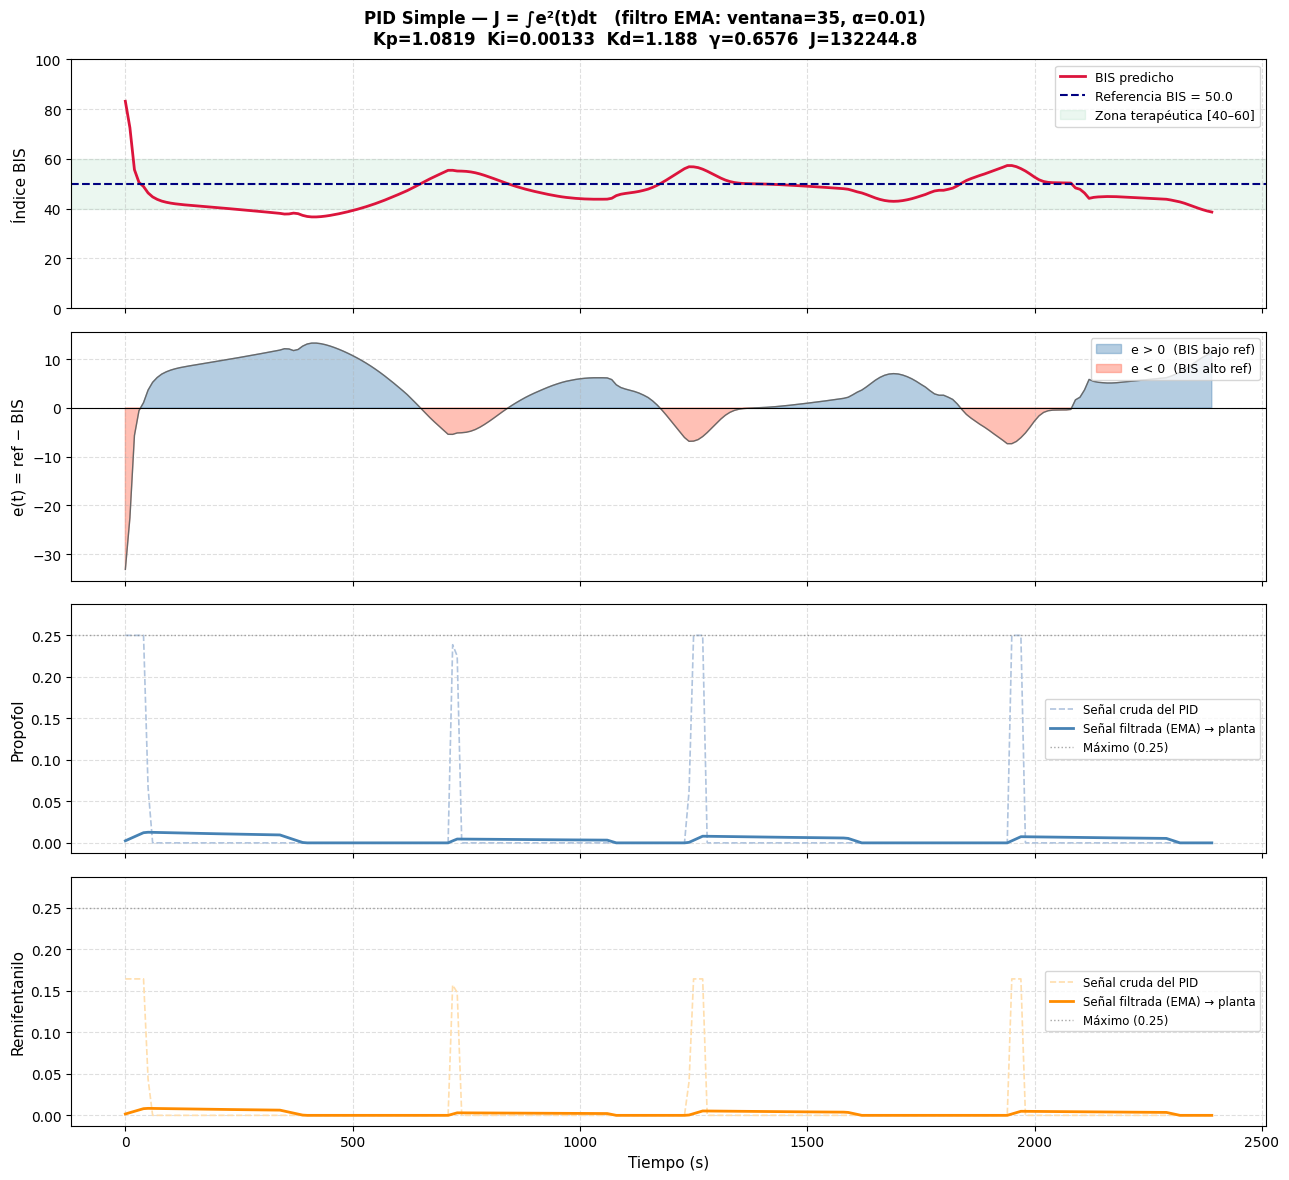

[INFO] Guardada: C:\Users\yordi\Desktop\exp1_pid_simple_lazo.png


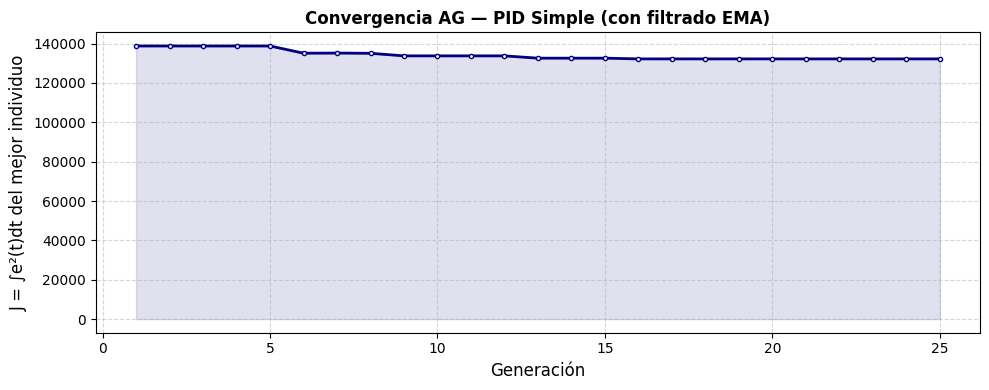

[INFO] Guardada: C:\Users\yordi\Desktop\exp1_pid_simple_convergencia.png


In [7]:
# =============================================================================
# EXPERIMENTO 1 — PARÁMETROS  
# =============================================================================

# ── Paciente ──────────────────────────────────────────────────────────────────
EDAD_E1, PESO_E1, ALTURA_E1, SEXO_E1 = 33, 85, 175, 0

# ── Parámetros de simulación ──────────────────────────────────────────────────
# ventana_ema, alfa_ema : hiperparámetros del filtro de media exponencial
#                         móvil aplicado a las señales de control antes de
#                         introducirse a la planta. 
cfg_sim_e1 = dict(
    bis_ref     = 50.0,
    bis_ini     = 98.0,
    T_sim       = 240,        # pasos   (T_sim × dt)
    T_ven       = 180,        # longitud de ventana del modelo [muestras]
    dt          = 10.0,       # período de muestreo [s]
    ppf_max     = 0.25,
    remi_max    = 0.25,
    ventana_ema = VENTANA_EMA,   
    alfa_ema    = ALFA_EMA,      
)

# ── Espacio de búsqueda [Kp, Ki, Kd, gamma] ──────────────────────────────────
limites_inf_e1 = [1e-8, 1e-8, 1e-8, 1e-8]  # valores mínimos de cada parámetro
limites_sup_e1 = [2.0,  2.0,     2.0,  1.0] # valores máximos de cada parámetro
nombres_e1     = ["Kp", "Ki", "Kd", "gamma"]

# ── Algoritmo genético ────────────────────────────────────────────────────────
cfg_ag_e1 = dict(
    n_pop              = 3000,
    n_elite            = 1200,
    n_gen              = 25,
    prob_mut_global    = 0.6,    #  % de los hijos mutan
    fraccion_gaussiana = 0.8,    # 80 % gaussiana / 20 % uniforme
    sigma_mut          = 0.7,
)

# =============================================================================
# EJECUCIÓN — SINTONIZACIÓN CON J = ∫e²(t)dt
# =============================================================================
cov_e1    = hacer_cov_tensor(EDAD_E1, PESO_E1, ALTURA_E1, SEXO_E1)
lim_inf_t = torch.tensor(limites_inf_e1, dtype=torch.float32, device=dispositivo)
lim_sup_t = torch.tensor(limites_sup_e1, dtype=torch.float32, device=dispositivo)

elite_e1, hist_e1, hist_params_e1 = ejecutar_ag(
    simular_lote_pid_simple, cov_e1,
    lim_inf_t, lim_sup_t,
    cfg_sim_e1, cfg_ag_e1, nombres_e1,
    encabezado="SINTONIZACIÓN PID SIMPLE — J = ∫e²(t)dt  (con filtrado EMA)"
)

mejor_e1 = elite_e1[0]

# =============================================================================
# IMPRESIÓN DE PARÁMETROS RESULTANTES EN CONSOLA
# =============================================================================
ancho = 65
print("\n" + "=" * ancho)
print("  RESULTADO FINAL — PID SIMPLE (con filtrado EMA)")
print(f"  Paciente: Edad={EDAD_E1} años  Peso={PESO_E1} kg  "
      f"Altura={ALTURA_E1} cm  Sexo={'M' if SEXO_E1==0 else 'F'}")
print(f"  Filtro EMA: ventana={cfg_sim_e1['ventana_ema']}  "
      f"α={cfg_sim_e1['alfa_ema']}")
print("─" * ancho)
for j, n in enumerate(nombres_e1):
    print(f"  {n:>8} = {mejor_e1[j].item():.8f}")
print(f"  {'J óptimo':>8} = {hist_e1[-1]:.4f}")
print("=" * ancho)

# =============================================================================
# SIMULACIÓN FINAL CON EL MEJOR INDIVIDUO
# =============================================================================
eje_t_e1 = np.arange(cfg_sim_e1["T_sim"]) * cfg_sim_e1["dt"]

(costo_final_e1, ppf_filt_e1, remi_filt_e1, bis_e1,
 ppf_raw_e1, remi_raw_e1) = simular_lote_pid_simple(
    mejor_e1.unsqueeze(0), cov_e1, **cfg_sim_e1
)

bis_np_e1       = bis_e1.squeeze(0).cpu().numpy()
ppf_filt_np_e1  = ppf_filt_e1.squeeze(0).cpu().numpy()
remi_filt_np_e1 = remi_filt_e1.squeeze(0).cpu().numpy()
ppf_raw_np_e1   = ppf_raw_e1.squeeze(0).cpu().numpy()
remi_raw_np_e1  = remi_raw_e1.squeeze(0).cpu().numpy()

# =============================================================================
# GRÁFICAS
# =============================================================================
titulo_e1 = (
    f"PID Simple — J = ∫e²(t)dt   (filtro EMA: ventana="
    f"{cfg_sim_e1['ventana_ema']}, α={cfg_sim_e1['alfa_ema']})\n"
    f"Kp={mejor_e1[0].item():.4f}  Ki={mejor_e1[1].item():.5f}  "
    f"Kd={mejor_e1[2].item():.3f}  γ={mejor_e1[3].item():.4f}  "
    f"J={hist_e1[-1]:.1f}"
)
graficar_lazo(
    bis_np_e1, ppf_filt_np_e1, remi_filt_np_e1,
    ppf_raw_np_e1, remi_raw_np_e1, eje_t_e1,
    cfg_sim_e1["bis_ref"], cfg_sim_e1["ppf_max"], cfg_sim_e1["remi_max"],
    titulo_e1, "exp1_pid_simple_lazo.png"
)

graficar_convergencia(
    hist_e1,
    "Convergencia AG — PID Simple (con filtrado EMA)",
    "exp1_pid_simple_convergencia.png"
)


## Experimento 2 — PID Dual
Dos PID independientes: uno para propofol y otro para remifentanilo. Variables de optimización: `[Kp_p, Ki_p, Kd_p, Kp_r, Ki_r, Kd_r].

Función de costo: `J = ∫ e²(t) dt`.

Ambas señales de control se filtran de manera independiente mediante la misma media exponencial móvil antes de introducirse a la planta.


  SINTONIZACIÓN PID DUAL — J = ∫e²(t)dt  (con filtrado EMA)
  Gen   1/25  Costo= 135430.86  Kp_p=1.2394  Ki_p=0.0012  Kd_p=1.8291  Kp_r=2.1209  [27.8s]
  Gen   2/25  Costo= 135271.02  Kp_p=2.5000  Ki_p=0.0093  Kd_p=1.0317  Kp_r=2.0727  [27.7s]
  Gen   3/25  Costo= 134294.98  Kp_p=2.2007  Ki_p=0.0048  Kd_p=2.0434  Kp_r=2.0865  [27.8s]
  Gen   4/25  Costo= 131977.12  Kp_p=1.2338  Ki_p=0.0015  Kd_p=0.7340  Kp_r=2.1345  [27.8s]
  Gen   5/25  Costo= 123953.17  Kp_p=0.0449  Ki_p=0.0000  Kd_p=0.0000  Kp_r=2.5000  [27.7s]
  Gen   6/25  Costo= 123953.17  Kp_p=0.0449  Ki_p=0.0000  Kd_p=0.0000  Kp_r=2.5000  [27.7s]
  Gen   7/25  Costo= 123953.17  Kp_p=0.0449  Ki_p=0.0000  Kd_p=0.0000  Kp_r=2.5000  [27.8s]
  Gen   8/25  Costo= 123953.17  Kp_p=0.0449  Ki_p=0.0000  Kd_p=0.0000  Kp_r=2.5000  [27.7s]
  Gen   9/25  Costo= 123953.17  Kp_p=0.0449  Ki_p=0.0000  Kd_p=0.0000  Kp_r=2.5000  [28.2s]
  Gen  10/25  Costo= 123953.17  Kp_p=0.0449  Ki_p=0.0000  Kd_p=0.0000  Kp_r=2.5000  [28.3s]
  Gen  11/25  Costo

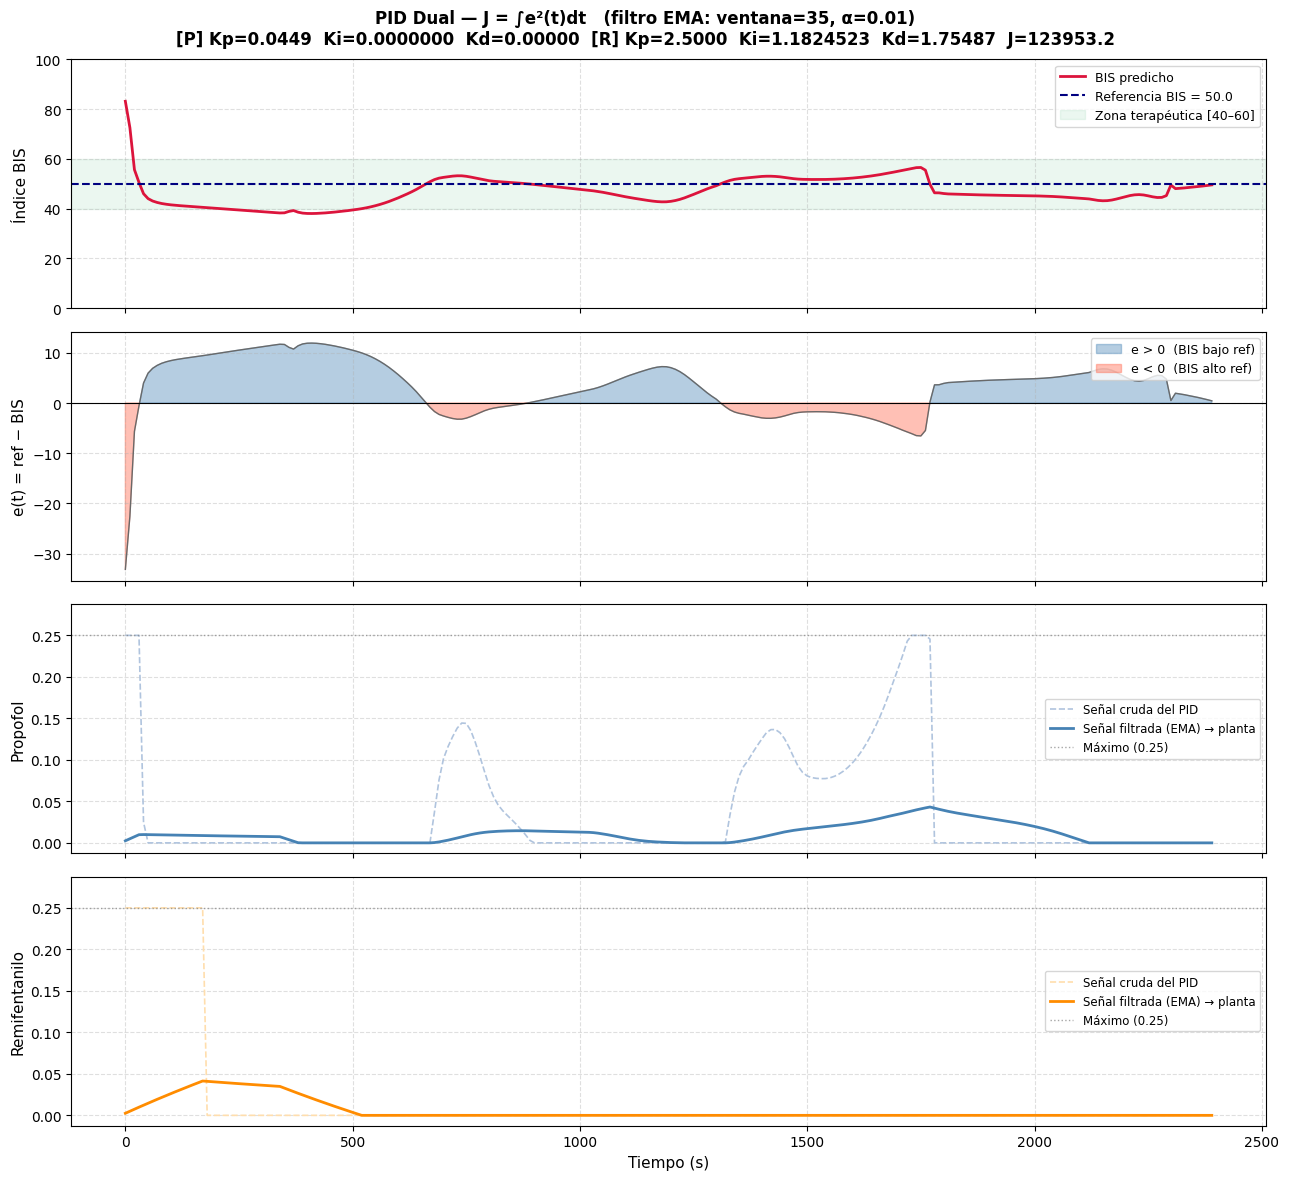

[INFO] Guardada: C:\Users\yordi\Desktop\exp2_pid_dual_lazo.png


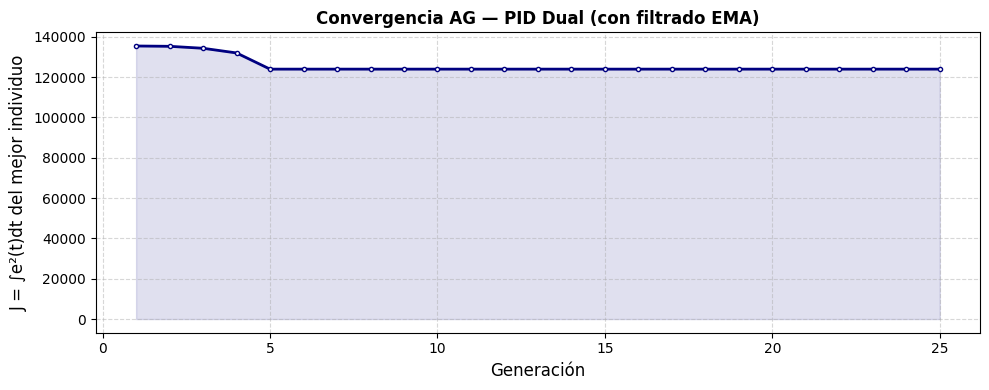

[INFO] Guardada: C:\Users\yordi\Desktop\exp2_pid_dual_convergencia.png


In [8]:
# =============================================================================
# EXPERIMENTO 2 — PARÁMETROS  
# =============================================================================

# ── Paciente ──────────────────────────────────────────────────────────────────
EDAD_E2, PESO_E2, ALTURA_E2, SEXO_E2 = 33, 85, 175, 0

# ── Parámetros de simulación ──────────────────────────────────────────────────
cfg_sim_e2 = dict(
    bis_ref     = 50.0,
    bis_ini     = 98.0,
    T_sim       = 240,
    T_ven       = 180,
    dt          = 10.0,
    ppf_max     = 0.25,
    remi_max    = 0.25,
    ventana_ema = VENTANA_EMA,   
    alfa_ema    = ALFA_EMA,     
)

# ── Espacio de búsqueda [Kp_p, Ki_p, Kd_p, Kp_r, Ki_r, Kd_r] ────────────────
limites_inf_e2 = [1e-8, 1e-8, 1e-8, 1e-8, 1e-8, 1e-8] # Valores mínimos de cada parámetro
limites_sup_e2 = [2.5, 2.5, 2.5, 2.5, 2.5, 2.5] # Valores máximos de cada parámetro
nombres_e2     = ["Kp_p", "Ki_p", "Kd_p", "Kp_r", "Ki_r", "Kd_r"]

# ── Algoritmo genético ────────────────────────────────────────────────────────
cfg_ag_e2 = dict(
    n_pop              = 3000,
    n_elite            = 800,
    n_gen              = 25,
    prob_mut_global    = 0.6,    # 60 % de los hijos mutan
    fraccion_gaussiana = 0.8,    # 80 % gaussiana / 20 % uniforme
    sigma_mut          = 0.8,
)

# =============================================================================
# EJECUCIÓN — SINTONIZACIÓN CON J = ∫e²(t)dt
# =============================================================================
cov_e2    = hacer_cov_tensor(EDAD_E2, PESO_E2, ALTURA_E2, SEXO_E2)
lim_inf_t = torch.tensor(limites_inf_e2, dtype=torch.float32, device=dispositivo)
lim_sup_t = torch.tensor(limites_sup_e2, dtype=torch.float32, device=dispositivo)

elite_e2, hist_e2, hist_params_e2 = ejecutar_ag(
    simular_lote_pid_dual, cov_e2,
    lim_inf_t, lim_sup_t,
    cfg_sim_e2, cfg_ag_e2, nombres_e2,
    encabezado="SINTONIZACIÓN PID DUAL — J = ∫e²(t)dt  (con filtrado EMA)"
)

mejor_e2 = elite_e2[0]

# =============================================================================
# IMPRESIÓN DE PARÁMETROS RESULTANTES EN CONSOLA
# =============================================================================
ancho = 68
print("\n" + "=" * ancho)
print("  RESULTADO FINAL — PID DUAL (con filtrado EMA)")
print(f"  Paciente: Edad={EDAD_E2} años  Peso={PESO_E2} kg  "
      f"Altura={ALTURA_E2} cm  Sexo={'M' if SEXO_E2==0 else 'F'}")
print(f"  Filtro EMA: ventana={cfg_sim_e2['ventana_ema']}  "
      f"α={cfg_sim_e2['alfa_ema']}")
print("─" * ancho)
for j, n in enumerate(nombres_e2):
    print(f"  {n:>8} = {mejor_e2[j].item():.8f}")
print(f"  {'J óptimo':>8} = {hist_e2[-1]:.4f}")
print("=" * ancho)

# =============================================================================
# SIMULACIÓN FINAL CON EL MEJOR INDIVIDUO
# =============================================================================
eje_t_e2 = np.arange(cfg_sim_e2["T_sim"]) * cfg_sim_e2["dt"]

(costo_final_e2, ppf_filt_e2, remi_filt_e2, bis_e2,
 ppf_raw_e2, remi_raw_e2) = simular_lote_pid_dual(
    mejor_e2.unsqueeze(0), cov_e2, **cfg_sim_e2
)

bis_np_e2       = bis_e2.squeeze(0).cpu().numpy()
ppf_filt_np_e2  = ppf_filt_e2.squeeze(0).cpu().numpy()
remi_filt_np_e2 = remi_filt_e2.squeeze(0).cpu().numpy()
ppf_raw_np_e2   = ppf_raw_e2.squeeze(0).cpu().numpy()
remi_raw_np_e2  = remi_raw_e2.squeeze(0).cpu().numpy()

# =============================================================================
# GRÁFICAS
# =============================================================================
titulo_e2 = (
    f"PID Dual — J = ∫e²(t)dt   (filtro EMA: ventana="
    f"{cfg_sim_e2['ventana_ema']}, α={cfg_sim_e2['alfa_ema']})\n"
    f"[P] Kp={mejor_e2[0].item():.4f}  Ki={mejor_e2[1].item():.7f}  "
    f"Kd={mejor_e2[2].item():.5f}  "
    f"[R] Kp={mejor_e2[3].item():.4f}  Ki={mejor_e2[4].item():.7f}  "
    f"Kd={mejor_e2[5].item():.5f}  "
    f"J={hist_e2[-1]:.1f}"
)
graficar_lazo(
    bis_np_e2, ppf_filt_np_e2, remi_filt_np_e2,
    ppf_raw_np_e2, remi_raw_np_e2, eje_t_e2,
    cfg_sim_e2["bis_ref"], cfg_sim_e2["ppf_max"], cfg_sim_e2["remi_max"],
    titulo_e2, "exp2_pid_dual_lazo.png"
)

graficar_convergencia(
    hist_e2,
    "Convergencia AG — PID Dual (con filtrado EMA)",
    "exp2_pid_dual_convergencia.png"
)


##  Sintonización poblacional: PID Proporcional y Dual


  HIPERPARÁMETROS DEL FILTRO DE MEDIA EXPONENCIAL MÓVIL (EMA)
  Longitud de la ventana deslizante (VENTANA_EMA) : 35
  Factor de suavizado               (ALFA_EMA)    : 0.01

  PACIENTE  1/18  |  Edad=69  Peso=62.8 kg  Altura=166.5 cm  Sexo=M
  Controlador: PID SIMPLE — J = ∫e²(t)dt  (con filtrado EMA)

  PID Simple — Pac. 1 (M, 69a, 62.8kg)
  Gen   1/30  Costo= 149446.47  Kp=2.1318  Ki=0.0073  Kd=2.2629  gamma=0.7697  [11.8s]
  Gen   2/30  Costo= 146698.84  Kp=0.8248  Ki=0.0000  Kd=2.5000  gamma=1.0000  [11.6s]
  Gen   3/30  Costo= 141785.34  Kp=0.4829  Ki=0.0000  Kd=2.2669  gamma=1.0000  [11.6s]
  Gen   4/30  Costo= 130916.59  Kp=1.3755  Ki=0.0000  Kd=2.0523  gamma=1.0000  [11.6s]
  Gen   5/30  Costo= 127058.76  Kp=1.4865  Ki=0.0000  Kd=2.2256  gamma=0.6412  [11.6s]
  Gen   6/30  Costo= 128290.24  Kp=1.4865  Ki=0.0000  Kd=2.2256  gamma=0.6412  [11.6s]
  Gen   7/30  Costo= 127889.01  Kp=1.4865  Ki=0.0000  Kd=2.2256  gamma=0.6412  [11.6s]
  Gen   8/30  Costo= 127058.76  Kp=1.4865  Ki=0

,Paciente,Edad,Peso_kg,Altura_cm,Sexo,Controlador,Kp,Ki,Kd,gamma,Kp_p,Ki_p,Kd_p,Kp_r,Ki_r,Kd_r,RMSE
0,1,69,62.80,166.5,M,PID Simple,1.743900,2.958015e-03,1.539003,7.288930e-01,NaN,NaN,NaN,NaN,NaN,NaN,6.881680
1,1,69,62.80,166.5,M,PID Dual,NaN,NaN,NaN,NaN,2.063910e+00,1.000000e-08,2.097567e+00,7.803211e-01,1.000000e-08,2.500000,6.923927
2,2,46,81.80,174.5,M,PID Simple,0.048734,1.000000e-08,2.061485,1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,6.717291
3,2,46,81.80,174.5,M,PID Dual,NaN,NaN,NaN,NaN,1.298412e+00,1.002814e-03,8.313476e-01,1.094333e+00,1.590801e-01,1.321465,6.904529
4,3,38,62.00,175.0,M,PID Simple,0.827532,1.873997e-03,1.566836,6.289859e-01,NaN,NaN,NaN,NaN,NaN,NaN,6.502062
5,3,38,62.00,175.0,M,PID Dual,NaN,NaN,NaN,NaN,1.655538e+00,1.000000e-08,2.339307e+00,4.039452e-01,1.000000e-08,0.313259,8.624792
6,4,69,68.25,170.0,M,PID Simple,1.868677,2.700546e-03,1.899501,6.895635e-01,NaN,NaN,NaN,NaN,NaN,NaN,7.152712
7,4,69,68.25,170.0,M,PID Dual,NaN,NaN,NaN,NaN,1.933964e+00,3.406785e-03,4.495141e-01,1.120050e+00,1.626362e+00,1.279819,6.790660
8,5,58,82.80,166.4,M,PID Simple,1.541741,1.829996e-03,2.069427,5.730525e-01,NaN,NaN,NaN,NaN,NaN,NaN,7.021137
9,5,58,82.80,166.4,M,PID Dual,NaN,NaN,NaN,NaN,7.170820e-02,1.000000e-08,1.000000e-08,1.000000e-08,1.476012e+00,0.250184,6.777669



  ESTADÍSTICAS RESUMEN DEL RMSE  (n = 18 pacientes)
  Controlador        Media RMSE    Desv. estándar
  ──────────────────────────────────────────────────────────────────
  PID Simple             5.3825            1.5745
  PID Dual               5.3772            1.6460


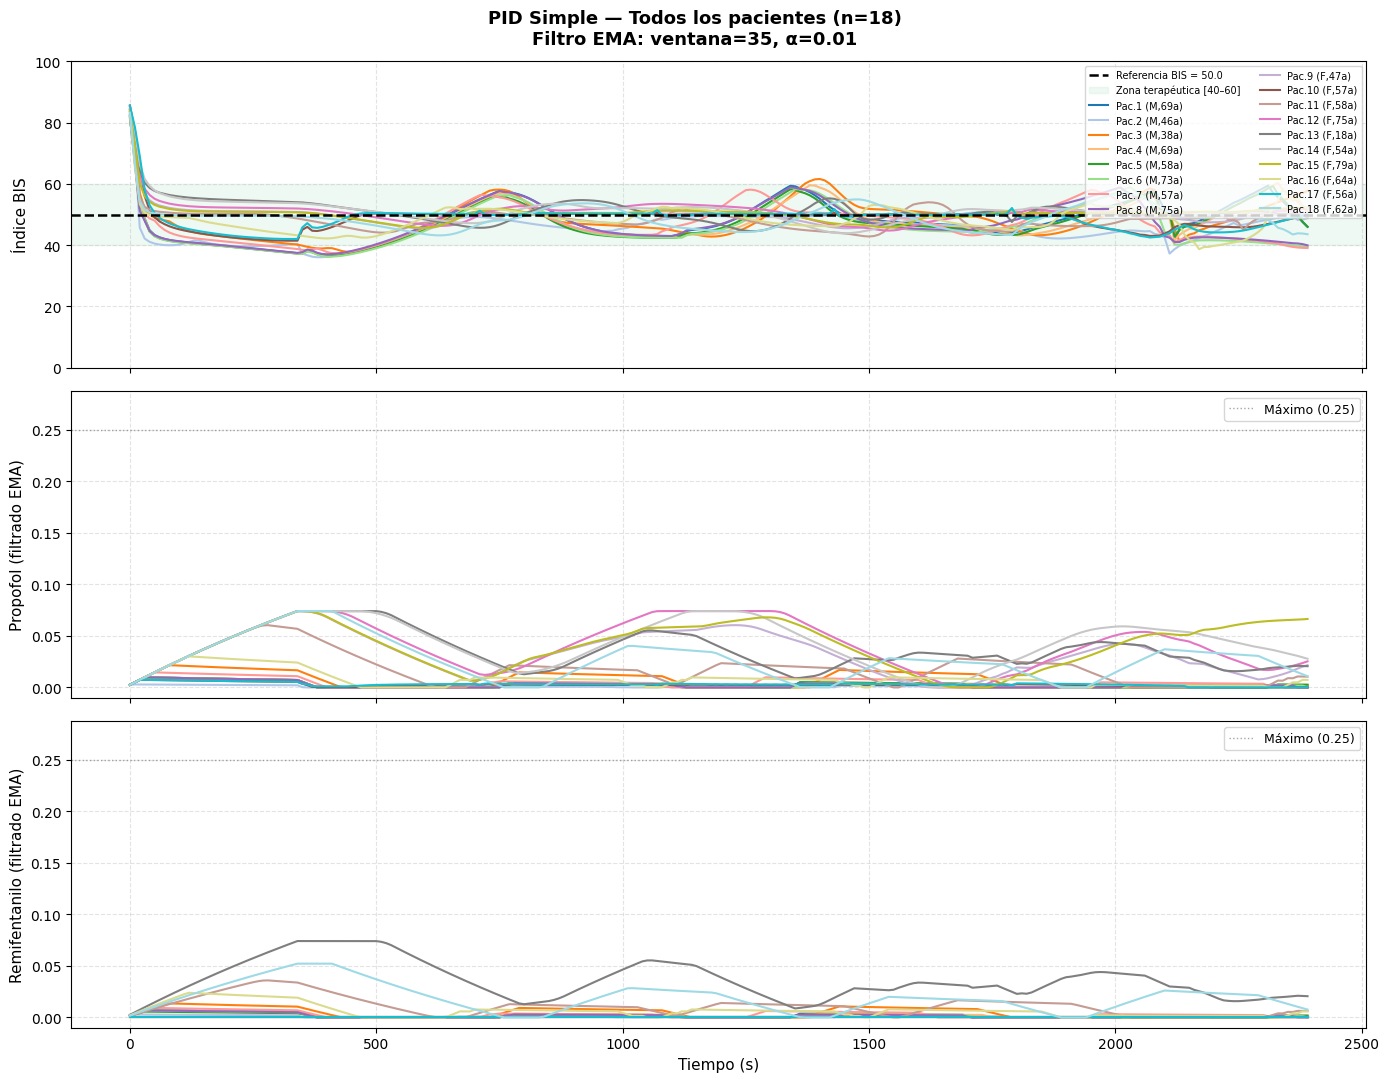

[INFO] Guardada: C:\Users\yordi\Desktop\exp3_pid_simple_poblacion.png


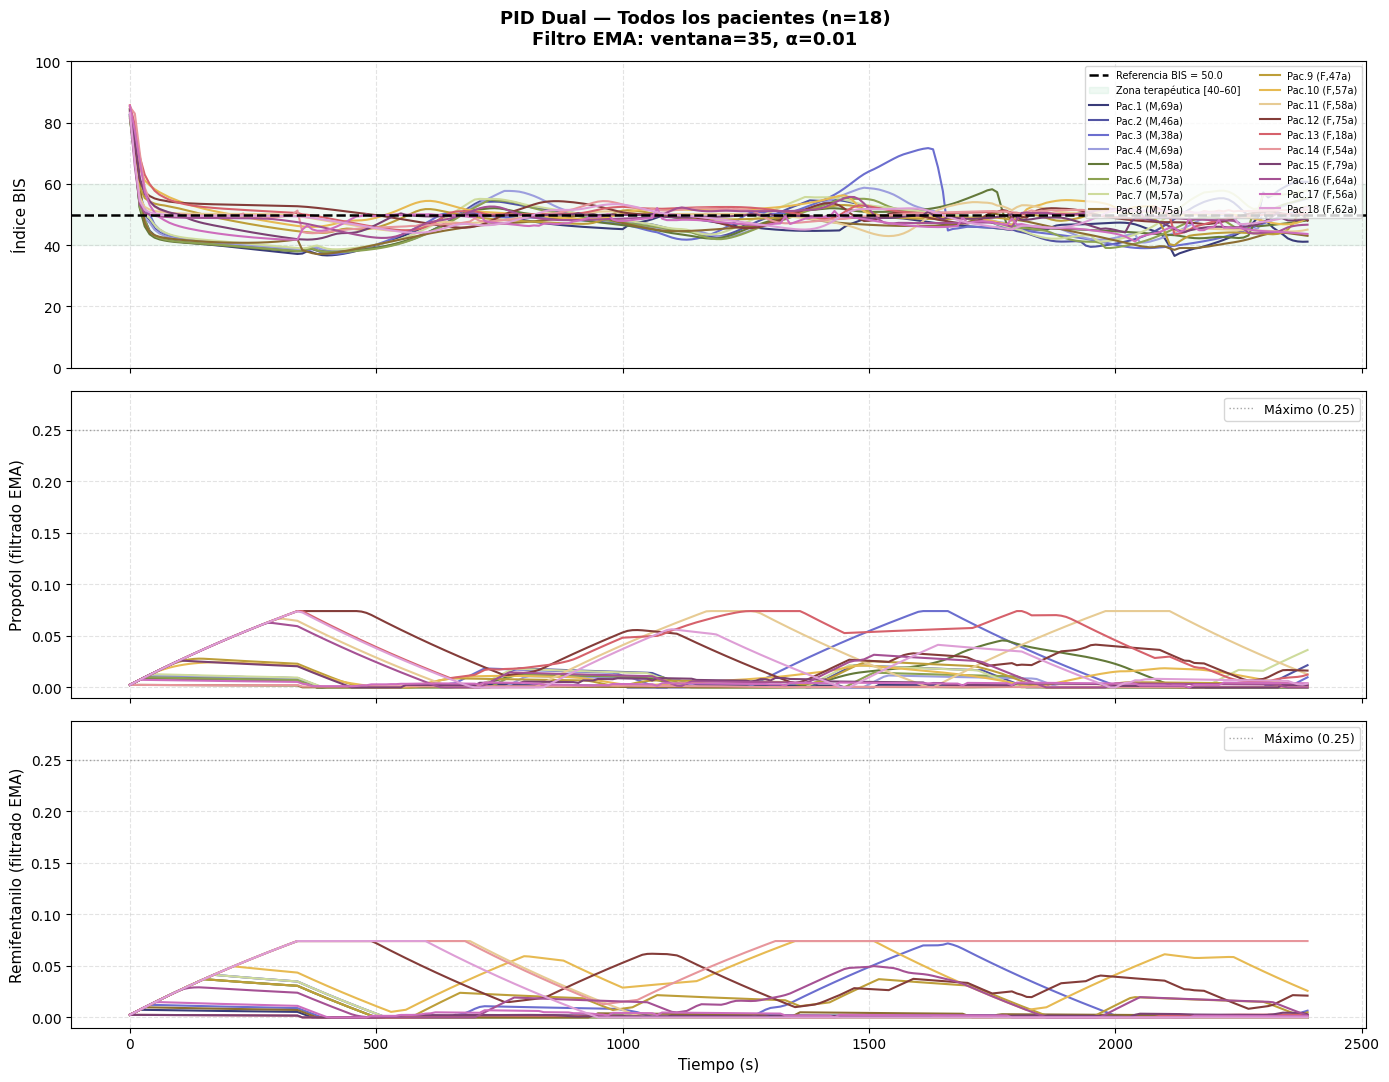

[INFO] Guardada: C:\Users\yordi\Desktop\exp3_pid_dual_poblacion.png


In [ ]:

# Para cada uno de los 18 pacientes listados a continuación se sintonizan,
# de manera independiente, tanto el PID Simple como el PID Dual, empleando
# el Algoritmo Genético y la arquitectura de filtrado por media exponencial
# móvil (EMA). Para cada sintonización se calcula
# el RMSE (raíz del error cuadrático medio) de la respuesta BIS respecto
# a la referencia constante.
#
# Los resultados —datos del paciente, hiperparámetros del mejor controlador
# obtenido y RMSE— se organizan en un DataFrame.
#
# Las figuras finales muestran, para cada controlador por separado, la
# respuesta BIS y las señales de control de todos los pacientes
# superpuestas.

import pandas as pd
import matplotlib.cm as cm

# =============================================================================
#  DATOS DE LOS PACIENTES
# =============================================================================

# Cada entrada es una tupla (Edad, Peso[kg], Altura[cm], Sexo[0=M, 1=F])
PACIENTES = [
    (69, 62.80, 166.5, 0),
    (46, 81.80, 174.5, 0),
    (38, 62.00, 175.0, 0),
    (69, 68.25, 170.0, 0),
    (58, 82.80, 166.4, 0),
    (73, 72.30, 172.6, 0),
    (57, 58.00, 167.9, 0),
    (75, 65.80, 156.3, 0),
    (47, 71.20, 153.4, 1),
    (57, 51.35, 153.0, 1),
    (58, 70.80, 155.5, 1),
    (75, 53.30, 151.7, 1),
    (18, 62.20, 160.6, 1),
    (54, 56.80, 151.8, 1),
    (79, 59.70, 150.2, 1),
    (64, 66.95, 160.6, 1),
    (56, 48.50, 152.0, 1),
    (62, 68.20, 158.0, 1),
]
N_PACIENTES = len(PACIENTES)


# =============================================================================
# IMPRESIÓN DE LOS HIPERPARÁMETROS DEL FILTRO EMA
# =============================================================================

print("=" * 68)
print("  HIPERPARÁMETROS DEL FILTRO DE MEDIA EXPONENCIAL MÓVIL (EMA)")
print("=" * 68)
print(f"  Longitud de la ventana deslizante (VENTANA_EMA) : {VENTANA_EMA}")
print(f"  Factor de suavizado               (ALFA_EMA)    : {ALFA_EMA}")
print("=" * 68)


# =============================================================================
# PARÁMETROS DE SIMULACIÓN Y DEL ALGORITMO GENÉTICO
# =============================================================================

# ── PID Simple ────────────────────────────────────────────────────────────────
cfg_sim_pob_simple = dict(
    bis_ref     = 50.0,
    bis_ini     = 90.0,
    T_sim       = 240,
    T_ven       = 180,
    dt          = 10.0,
    ppf_max     = 0.25,
    remi_max    = 0.25,
    ventana_ema = VENTANA_EMA,
    alfa_ema    = ALFA_EMA,
)
limites_inf_pob_simple = [1e-8, 1e-8, 1e-8, 1e-8]
limites_sup_pob_simple = [2.5,2.5,2.5,  1.0]
nombres_pob_simple     = ["Kp", "Ki", "Kd", "gamma"]
cfg_ag_pob_simple = dict(
    n_pop=1250, n_elite=800, n_gen=30,
    prob_mut_global=0.55, fraccion_gaussiana=0.8, sigma_mut=0.7,
)

# ── PID Dual ──────────────────────────────────────────────────────────────────
cfg_sim_pob_dual = dict(
    bis_ref     = 50.0,
    bis_ini     = 98.0,
    T_sim       = 240,
    T_ven       = 180,
    dt          = 10.0,
    ppf_max     = 0.25,
    remi_max    = 0.25,
    ventana_ema = VENTANA_EMA,
    alfa_ema    = ALFA_EMA,
)
limites_inf_pob_dual = [1e-8, 1e-8, 1e-8, 1e-8, 1e-8, 1e-8]
limites_sup_pob_dual = [2.5, 2.5, 2.5, 2.5, 2.5, 2.5]
nombres_pob_dual     = ["Kp_p", "Ki_p", "Kd_p", "Kp_r", "Ki_r", "Kd_r"]
cfg_ag_pob_dual = dict(
    n_pop=1250, n_elite=800, n_gen=30,
    prob_mut_global=0.55, fraccion_gaussiana=0.8, sigma_mut=0.8,
)

lim_inf_pob_simple_t = torch.tensor(limites_inf_pob_simple, dtype=torch.float32, device=dispositivo)
lim_sup_pob_simple_t = torch.tensor(limites_sup_pob_simple, dtype=torch.float32, device=dispositivo)
lim_inf_pob_dual_t   = torch.tensor(limites_inf_pob_dual,   dtype=torch.float32, device=dispositivo)
lim_sup_pob_dual_t   = torch.tensor(limites_sup_pob_dual,   dtype=torch.float32, device=dispositivo)


eje_t_pob = np.arange(cfg_sim_pob_simple["T_sim"]) * cfg_sim_pob_simple["dt"]


# =============================================================================
# BARRIDO POBLACIONAL — SINTONIZACIÓN DE AMBOS CONTROLADORES
# =============================================================================

registros_pob = []          # Filas del DataFrame final, una por paciente y controlador.
historiales_pob_simple = [] # Señales filtradas para la figura del PID Simple
historiales_pob_dual   = [] # Señales filtradas para la figura del PID Dual

for idx_pac, (edad, peso, altura, sexo) in enumerate(PACIENTES, start=1):

    sexo_str = "M" if sexo == 0 else "F"
    cov_pac  = hacer_cov_tensor(edad, peso, altura, sexo)
    sep      = "=" * 68

    # ── PID Simple ────────────────────────────────────────────────────────────
    print(f"\n{sep}")
    print(f"  PACIENTE {idx_pac:2d}/{N_PACIENTES}  |  Edad={edad}  Peso={peso} kg  "
          f"Altura={altura} cm  Sexo={sexo_str}")
    print(f"  Controlador: PID SIMPLE — J = ∫e²(t)dt  (con filtrado EMA)")
    print(sep)

    elite_s, hist_s, _ = ejecutar_ag(
        simular_lote_pid_simple, cov_pac,
        lim_inf_pob_simple_t, lim_sup_pob_simple_t,
        cfg_sim_pob_simple, cfg_ag_pob_simple, nombres_pob_simple,
        encabezado=f"PID Simple — Pac. {idx_pac} ({sexo_str}, {edad}a, {peso}kg)"
    )
    mejor_s = elite_s[0]

    (_, ppf_filt_s_t, remi_filt_s_t, bis_s_t,
     _, _) = simular_lote_pid_simple(mejor_s.unsqueeze(0), cov_pac, **cfg_sim_pob_simple)

    bis_np_s       = bis_s_t.squeeze(0).cpu().numpy()
    ppf_filt_np_s  = ppf_filt_s_t.squeeze(0).cpu().numpy()
    remi_filt_np_s = remi_filt_s_t.squeeze(0).cpu().numpy()
    rmse_s = float(np.sqrt(np.mean((bis_np_s - cfg_sim_pob_simple["bis_ref"]) ** 2)))

    print(f"\n  ► RMSE PID Simple (Pac. {idx_pac}): {rmse_s:.4f}")
    for j, nm in enumerate(nombres_pob_simple):
        print(f"    {nm:<8} = {mejor_s[j].item():.8f}")

    historiales_pob_simple.append({
        "bis"     : bis_np_s,
        "ppf"     : ppf_filt_np_s,
        "remi"    : remi_filt_np_s,
        "etiqueta": f"Pac.{idx_pac} ({sexo_str},{edad}a)",
    })

    registros_pob.append({
        "Paciente"   : idx_pac, "Edad": edad, "Peso_kg": peso,
        "Altura_cm"  : altura,  "Sexo": sexo_str,
        "Controlador": "PID Simple",
        "Kp"         : mejor_s[0].item(), "Ki": mejor_s[1].item(),
        "Kd"         : mejor_s[2].item(), "gamma": mejor_s[3].item(),
        "Kp_p": None, "Ki_p": None, "Kd_p": None,
        "Kp_r": None, "Ki_r": None, "Kd_r": None,
        "RMSE"       : rmse_s,
    })

    # ── PID Dual ──────────────────────────────────────────────────────────────
    print(f"\n{sep}")
    print(f"  PACIENTE {idx_pac:2d}/{N_PACIENTES}  |  Edad={edad}  Peso={peso} kg  "
          f"Altura={altura} cm  Sexo={sexo_str}")
    print(f"  Controlador: PID DUAL — J = ∫e²(t)dt  (con filtrado EMA)")
    print(sep)

    elite_d, hist_d, _ = ejecutar_ag(
        simular_lote_pid_dual, cov_pac,
        lim_inf_pob_dual_t, lim_sup_pob_dual_t,
        cfg_sim_pob_dual, cfg_ag_pob_dual, nombres_pob_dual,
        encabezado=f"PID Dual — Pac. {idx_pac} ({sexo_str}, {edad}a, {peso}kg)"
    )
    mejor_d = elite_d[0]

    (_, ppf_filt_d_t, remi_filt_d_t, bis_d_t,
     _, _) = simular_lote_pid_dual(mejor_d.unsqueeze(0), cov_pac, **cfg_sim_pob_dual)

    bis_np_d       = bis_d_t.squeeze(0).cpu().numpy()
    ppf_filt_np_d  = ppf_filt_d_t.squeeze(0).cpu().numpy()
    remi_filt_np_d = remi_filt_d_t.squeeze(0).cpu().numpy()
    rmse_d = float(np.sqrt(np.mean((bis_np_d - cfg_sim_pob_dual["bis_ref"]) ** 2)))

    print(f"\n  ► RMSE PID Dual (Pac. {idx_pac}): {rmse_d:.4f}")
    for j, nm in enumerate(nombres_pob_dual):
        print(f"    {nm:<8} = {mejor_d[j].item():.8f}")

    historiales_pob_dual.append({
        "bis"     : bis_np_d,
        "ppf"     : ppf_filt_np_d,
        "remi"    : remi_filt_np_d,
        "etiqueta": f"Pac.{idx_pac} ({sexo_str},{edad}a)",
    })

    registros_pob.append({
        "Paciente"   : idx_pac, "Edad": edad, "Peso_kg": peso,
        "Altura_cm"  : altura,  "Sexo": sexo_str,
        "Controlador": "PID Dual",
        "Kp": None, "Ki": None, "Kd": None, "gamma": None,
        "Kp_p"       : mejor_d[0].item(), "Ki_p": mejor_d[1].item(),
        "Kd_p"       : mejor_d[2].item(), "Kp_r": mejor_d[3].item(),
        "Ki_r"       : mejor_d[4].item(), "Kd_r": mejor_d[5].item(),
        "RMSE"       : rmse_d,
    })


# =============================================================================
# CONSTRUCCIÓN DEL DATAFRAME DE RESULTADOS
# =============================================================================

COLUMNAS_DF = [
    "Paciente", "Edad", "Peso_kg", "Altura_cm", "Sexo", "Controlador",
    "Kp", "Ki", "Kd", "gamma",
    "Kp_p", "Ki_p", "Kd_p", "Kp_r", "Ki_r", "Kd_r",
    "RMSE",
]
df_resultados_pob = pd.DataFrame(registros_pob, columns=COLUMNAS_DF)

print("\n" + "=" * 72)
print("  DATAFRAME DE RESULTADOS — SINTONIZACIÓN POBLACIONAL")
print("=" * 72)
try:
    display(df_resultados_pob)
except NameError:
    print(df_resultados_pob.to_string(index=False))


# =============================================================================
#  ESTADÍSTICAS RESUMEN — MEDIA Y DESVIACIÓN ESTÁNDAR DEL RMSE
# =============================================================================

df_simple_pob = df_resultados_pob[df_resultados_pob["Controlador"] == "PID Simple"]
df_dual_pob   = df_resultados_pob[df_resultados_pob["Controlador"] == "PID Dual"]

media_rmse_simple = float(df_simple_pob["RMSE"].mean())
std_rmse_simple   = float(df_simple_pob["RMSE"].std(ddof=1))
media_rmse_dual   = float(df_dual_pob["RMSE"].mean())
std_rmse_dual     = float(df_dual_pob["RMSE"].std(ddof=1))

ancho = 68
print("\n" + "=" * ancho)
print(f"  ESTADÍSTICAS RESUMEN DEL RMSE  (n = {N_PACIENTES} pacientes)")
print("=" * ancho)
print(f"  {'Controlador':<15}  {'Media RMSE':>12}  {'Desv. estándar':>16}")
print("  " + "─" * (ancho - 2))
print(f"  {'PID Simple':<15}  {media_rmse_simple:>12.4f}  {std_rmse_simple:>16.4f}")
print(f"  {'PID Dual':<15}  {media_rmse_dual:>12.4f}  {std_rmse_dual:>16.4f}")
print("=" * ancho)


# =============================================================================
#  FUNCIÓN AUXILIAR DE GRAFICADO POBLACIONAL
# =============================================================================

def graficar_poblacion_filtrada(historiales, titulo, ppf_max, remi_max,
                                 bis_ref, nombre_arch, colormap="tab20"):
    """
    Genera una figura de tres paneles (BIS, propofol filtrado y
    remifentanilo filtrado) que superpone las trayectorias de todos los
    pacientes de la población para un único controlador.


    Parámetros
    ----------
    historiales : lista de diccionarios {bis, ppf, remi, etiqueta}
    titulo      : título de la figura
    ppf_max     : límite de saturación del propofol
    remi_max    : límite de saturación del remifentanilo
    bis_ref     : referencia BIS constante
    nombre_arch : nombre del archivo PNG de salida
    colormap    : mapa de color de Matplotlib para diferenciar pacientes
    """
    N = len(historiales)
    colores = getattr(cm, colormap)(np.linspace(0, 1, N))

    fig, ejes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
    fig.suptitle(titulo, fontsize=13, fontweight="bold")

    # ── Panel 1: BIS ──────────────────────────────────────────────────────────
    ax = ejes[0]
    ax.axhline(bis_ref, color="black", lw=1.8, ls="--",
               label=f"Referencia BIS = {bis_ref}", zorder=3)
    ax.axhspan(40, 60, alpha=0.08, color="mediumseagreen",
               label="Zona terapéutica [40–60]", zorder=0)
    for i, h in enumerate(historiales):
        ax.plot(eje_t_pob, h["bis"], color=colores[i], lw=1.5,
                label=h["etiqueta"], zorder=2)
    ax.set_ylabel("Índice BIS", fontsize=11)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=7, loc="upper right", ncol=2)
    ax.grid(True, ls="--", alpha=0.35)

    # ── Panel 2: propofol filtrado ────────────────────────────────────────────
    ax = ejes[1]
    ax.axhline(ppf_max, color="gray", lw=1.0, ls=":", alpha=0.7,
               label=f"Máximo ({ppf_max})")
    for i, h in enumerate(historiales):
        ax.plot(eje_t_pob, h["ppf"], color=colores[i], lw=1.5)
    ax.set_ylabel("Propofol (filtrado EMA)", fontsize=11)
    ax.set_ylim(-0.01, ppf_max * 1.15)
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(True, ls="--", alpha=0.35)

    # ── Panel 3: remifentanilo filtrado ───────────────────────────────────────
    ax = ejes[2]
    ax.axhline(remi_max, color="gray", lw=1.0, ls=":", alpha=0.7,
               label=f"Máximo ({remi_max})")
    for i, h in enumerate(historiales):
        ax.plot(eje_t_pob, h["remi"], color=colores[i], lw=1.5)
    ax.set_ylabel("Remifentanilo (filtrado EMA)", fontsize=11)
    ax.set_xlabel("Tiempo (s)", fontsize=11)
    ax.set_ylim(-0.01, remi_max * 1.15)
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(True, ls="--", alpha=0.35)

    plt.tight_layout()
    ruta = os.path.join(RUTA_GRAFICAS, nombre_arch)
    plt.savefig(ruta, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[INFO] Guardada: {ruta}")


# =============================================================================
# FIGURAS 
# =============================================================================

graficar_poblacion_filtrada(
    historiales_pob_simple,
    f"PID Simple — Todos los pacientes (n={N_PACIENTES})\n"
    f"Filtro EMA: ventana={VENTANA_EMA}, α={ALFA_EMA}",
    cfg_sim_pob_simple["ppf_max"], cfg_sim_pob_simple["remi_max"],
    cfg_sim_pob_simple["bis_ref"],
    "exp3_pid_simple_poblacion.png", colormap="tab20"
)

graficar_poblacion_filtrada(
    historiales_pob_dual,
    f"PID Dual — Todos los pacientes (n={N_PACIENTES})\n"
    f"Filtro EMA: ventana={VENTANA_EMA}, α={ALFA_EMA}",
    cfg_sim_pob_dual["ppf_max"], cfg_sim_pob_dual["remi_max"],
    cfg_sim_pob_dual["bis_ref"],
    "exp3_pid_dual_poblacion.png", colormap="tab20b"
)


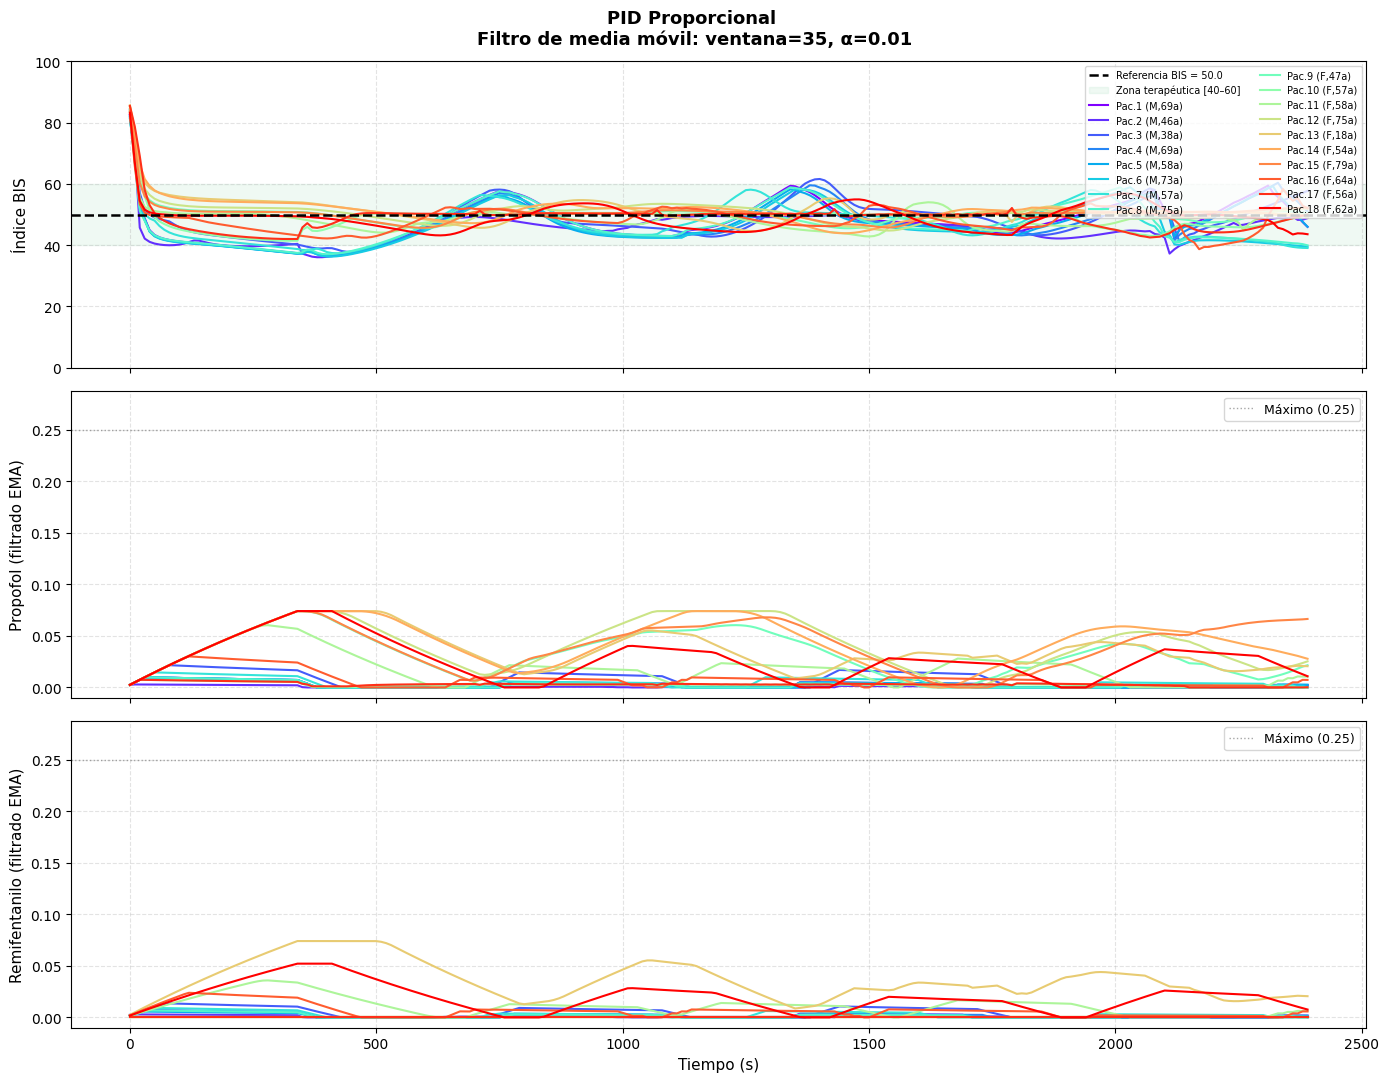

[INFO] Guardada: C:\Users\yordi\Desktop\exp3_pid_simple_poblacion.png


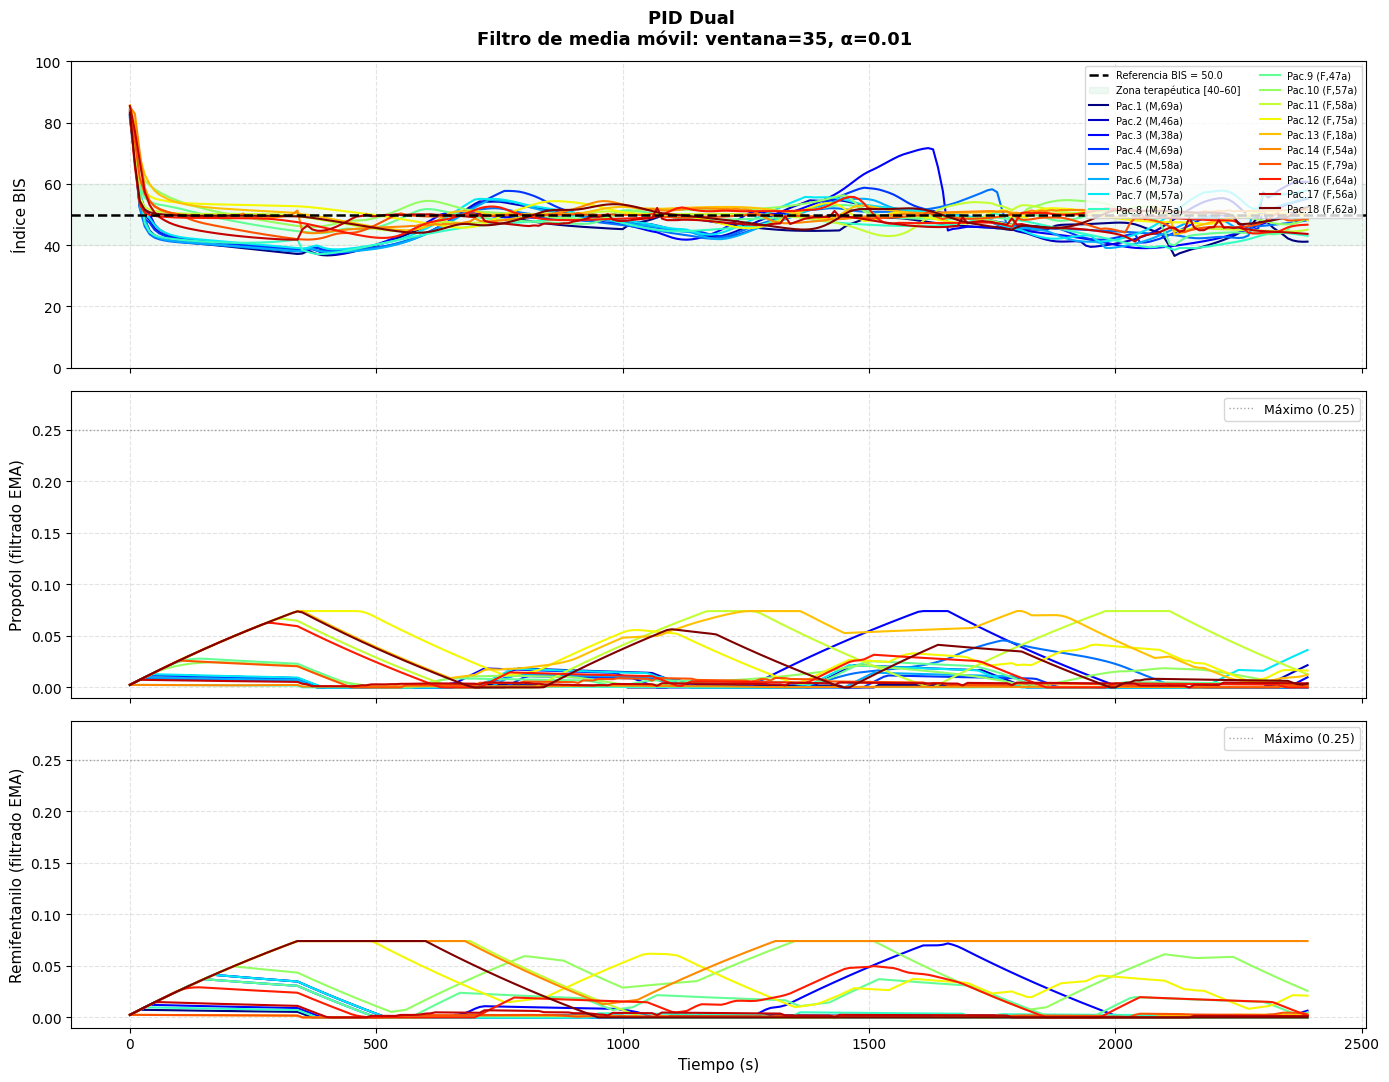

[INFO] Guardada: C:\Users\yordi\Desktop\exp3_pid_dual_poblacion.png


In [ ]:

def graficar_poblacion_filtrada(historiales, titulo, ppf_max, remi_max,
                                 bis_ref, nombre_arch, colormap="tab20"):
    """
    Genera una figura de tres paneles (BIS, propofol filtrado y
    remifentanilo filtrado) que superpone las trayectorias de todos los
    pacientes de la población para un único controlador.

    Parámetros
    ----------
    historiales : lista de diccionarios {bis, ppf, remi, etiqueta}
    titulo      : título de la figura
    ppf_max     : límite de saturación del propofol
    remi_max    : límite de saturación del remifentanilo
    bis_ref     : referencia BIS constante
    nombre_arch : nombre del archivo 
    colormap    : mapa de color de Matplotlib para diferenciar pacientes
    """
    N = len(historiales)
    colores = getattr(cm, colormap)(np.linspace(0, 1, N))

    fig, ejes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
    fig.suptitle(titulo, fontsize=13, fontweight="bold")

    # ── Panel 1: BIS ──────────────────────────────────────────────────────────
    ax = ejes[0]
    ax.axhline(bis_ref, color="black", lw=1.8, ls="--",
               label=f"Referencia BIS = {bis_ref}", zorder=3)
    ax.axhspan(40, 60, alpha=0.08, color="mediumseagreen",
               label="Zona terapéutica [40–60]", zorder=0)
    for i, h in enumerate(historiales):
        ax.plot(eje_t_pob, h["bis"], color=colores[i], lw=1.5,
                label=h["etiqueta"], zorder=2)
    ax.set_ylabel("Índice BIS", fontsize=11)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=7, loc="upper right", ncol=2)
    ax.grid(True, ls="--", alpha=0.35)

    # ── Panel 2: propofol filtrado ────────────────────────────────────────────
    ax = ejes[1]
    ax.axhline(ppf_max, color="gray", lw=1.0, ls=":", alpha=0.7,
               label=f"Máximo ({ppf_max})")
    for i, h in enumerate(historiales):
        ax.plot(eje_t_pob, h["ppf"], color=colores[i], lw=1.5)
    ax.set_ylabel("Propofol (filtrado EMA)", fontsize=11)
    ax.set_ylim(-0.01, ppf_max * 1.15)
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(True, ls="--", alpha=0.35)

    # ── Panel 3: remifentanilo filtrado ───────────────────────────────────────
    ax = ejes[2]
    ax.axhline(remi_max, color="gray", lw=1.0, ls=":", alpha=0.7,
               label=f"Máximo ({remi_max})")
    for i, h in enumerate(historiales):
        ax.plot(eje_t_pob, h["remi"], color=colores[i], lw=1.5)
    ax.set_ylabel("Remifentanilo (filtrado EMA)", fontsize=11)
    ax.set_xlabel("Tiempo (s)", fontsize=11)
    ax.set_ylim(-0.01, remi_max * 1.15)
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(True, ls="--", alpha=0.35)

    plt.tight_layout()
    ruta = os.path.join(RUTA_GRAFICAS, nombre_arch)
    plt.savefig(ruta, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[INFO] Guardada: {ruta}")


# =============================================================================
# FIGURAS 
# =============================================================================

graficar_poblacion_filtrada(
    historiales_pob_simple,
    f"PID Proporcional \n"
    f"Filtro de media móvil: ventana={VENTANA_EMA}, α={ALFA_EMA}",
    cfg_sim_pob_simple["ppf_max"], cfg_sim_pob_simple["remi_max"],
    cfg_sim_pob_simple["bis_ref"],
    "exp3_pid_simple_poblacion.png", colormap="rainbow"
)

graficar_poblacion_filtrada(
    historiales_pob_dual,
    f"PID Dual \n"
    f"Filtro de media móvil: ventana={VENTANA_EMA}, α={ALFA_EMA}",
    cfg_sim_pob_dual["ppf_max"], cfg_sim_pob_dual["remi_max"],
    cfg_sim_pob_dual["bis_ref"],
    "exp3_pid_dual_poblacion.png", colormap="jet"
)

## Comparación estadística de arquitecturas de control

In [ ]:

# Se evalúa si los valores de RMSE obtenidos para cada
# controlador (PID Simple y PID Dual) provienen de una distribución
# aproximadamente normal, mediante la prueba de Shapiro-Wilk.
#
# Dado que ambos controladores fueron sintonizados para los mismos 18
# pacientes, la comparación de las medias de RMSE constituye un problema
# de datos apareados. La elección entre una prueba paramétrica (t de
# Student apareada) y una prueba no paramétrica (Wilcoxon de rangos con
# signo) se basa en la normalidad de las diferencias apareadas
# (RMSE_Simple − RMSE_Dual), que es el supuesto que efectivamente
# condiciona la validez de la prueba t apareada.

from scipy import stats

ALFA = 0.05   # Nivel de significancia

# =============================================================================
# EXTRACCIÓN DE LOS VECTORES DE RMSE (APAREADOS POR PACIENTE)
# =============================================================================

rmse_simple_arr = df_simple_pob["RMSE"].values
rmse_dual_arr   = df_dual_pob["RMSE"].values
n_pac           = len(rmse_simple_arr)

ancho = 72

# =============================================================================
# PRUEBA DE NORMALIDAD DEL RMSE DE CADA CONTROLADOR
#            (prueba de Shapiro-Wilk)
#
# H₀ de esta prueba auxiliar: la muestra proviene de una
#            distribución normal.
# =============================================================================

est_sw_simple, p_sw_simple = stats.shapiro(rmse_simple_arr)
est_sw_dual,   p_sw_dual   = stats.shapiro(rmse_dual_arr)

normal_simple = p_sw_simple > ALFA
normal_dual   = p_sw_dual   > ALFA

print("\n" + "=" * ancho)
print("  PRUEBA DE NORMALIDAD DEL RMSE POR CONTROLADOR (SHAPIRO-WILK)")
print(f"  (n = {n_pac} pacientes)")
print("=" * ancho)
print(f"  {'Controlador':<15}  {'Estadístico W':>14}  {'p-valor':>10}  "
      f"{'¿Normal? (α=0.05)':>20}")
print("  " + "─" * (ancho - 2))
print(f"  {'PID Simple':<15}  {est_sw_simple:>14.4f}  {p_sw_simple:>10.6f}  "
      f"{'Sí' if normal_simple else 'No':>20}")
print(f"  {'PID Dual':<15}  {est_sw_dual:>14.4f}  {p_sw_dual:>10.6f}  "
      f"{'Sí' if normal_dual else 'No':>20}")
print("=" * ancho)


# =============================================================================
# PRUEBA DE NORMALIDAD DE LAS DIFERENCIAS APAREADAS
# =============================================================================

diferencias           = rmse_simple_arr - rmse_dual_arr
est_sw_dif, p_sw_dif  = stats.shapiro(diferencias)
diferencias_normales  = p_sw_dif > ALFA

print("\n  NORMALIDAD DE LAS DIFERENCIAS APAREADAS "
      "(RMSE_Simple − RMSE_Dual)")
print(f"    Estadístico W : {est_sw_dif:.4f}")
print(f"    p-valor       : {p_sw_dif:.6f}")
print(f"    Conclusión    : "
      f"{'no se rechaza normalidad' if diferencias_normales else 'se rechaza normalidad'} "
      f"(α = {ALFA})")
print("=" * ancho)


# =============================================================================
#SELECCIÓN Y EJECUCIÓN DE LA PRUEBA DE HIPÓTESIS PRINCIPAL
#
# H₀ : media(RMSE_Simple) = media(RMSE_Dual)
# H₁ : media(RMSE_Simple) ≠ media(RMSE_Dual)
#
# - Si las diferencias apareadas son aproximadamente normales,
#   se emplea la prueba t de Student para datos apareados.
# - En caso contrario, se emplea la prueba no paramétrica de
#   Wilcoxon de rangos con signo, apropiada para muestras
#   pequeñas y sin supuesto de normalidad.
# =============================================================================

if diferencias_normales:
    nombre_prueba = "t de Student para datos apareados"
    estadistico, p_valor = stats.ttest_rel(rmse_simple_arr, rmse_dual_arr)
else:
    nombre_prueba = "Wilcoxon de rangos con signo (no paramétrica)"
    estadistico, p_valor = stats.wilcoxon(rmse_simple_arr, rmse_dual_arr)

media_simple = float(np.mean(rmse_simple_arr))
std_simple   = float(np.std(rmse_simple_arr, ddof=1))
media_dual   = float(np.mean(rmse_dual_arr))
std_dual     = float(np.std(rmse_dual_arr, ddof=1))

print("\n" + "=" * ancho)
print("  COMPARACIÓN DE MEDIAS DE RMSE — PID SIMPLE vs PID DUAL")
print("=" * ancho)
print(f"  Pacientes analizados (n)   : {n_pac}")
print(f"  Media RMSE PID Simple      : {media_simple:.4f}  (± {std_simple:.4f})")
print(f"  Media RMSE PID Dual        : {media_dual:.4f}  (± {std_dual:.4f})")
print("─" * ancho)
print(f"  Prueba seleccionada : {nombre_prueba}")
print(f"  H₀ : media(RMSE_Simple) = media(RMSE_Dual)")
print(f"  H₁ : media(RMSE_Simple) ≠ media(RMSE_Dual)")
print("─" * ancho)
print(f"  Estadístico de prueba    : {estadistico:.4f}")
print(f"  p-valor (bilateral)      : {p_valor:.6f}")
print(f"  Nivel de significancia α : {ALFA}")
print("=" * ancho)


# =============================================================================
# CONCLUSIÓN
# =============================================================================

if p_valor < ALFA:
    if media_simple < media_dual:
        ganador, media_gan   = "PID SIMPLE", media_simple
        perdedor, media_per  = "PID DUAL",   media_dual
    else:
        ganador, media_gan   = "PID DUAL",   media_dual
        perdedor, media_per  = "PID SIMPLE", media_simple

    print(f"  CONCLUSIÓN: Se RECHAZA H₀  (p = {p_valor:.4f} < α = {ALFA}).")
    print(f"  Existe evidencia estadística suficiente para afirmar que el")
    print(f"  {ganador} presenta un RMSE promedio SIGNIFICATIVAMENTE MENOR")
    print(f"  que el {perdedor}.")
    print(f"  Media RMSE {ganador:<10}: {media_gan:.4f}")
    print(f"  Media RMSE {perdedor:<10}: {media_per:.4f}")
else:
    print(f"  CONCLUSIÓN: NO se rechaza H₀  (p = {p_valor:.4f} ≥ α = {ALFA}).")
    print(f"  No existe evidencia estadística suficiente para afirmar que")
    print(f"  un controlador presente un RMSE promedio significativamente")
    print(f"  menor que el otro; ambos exhiben un desempeño comparable en")
    print(f"  cuanto al RMSE.")

print("=" * ancho)



  PRUEBA DE NORMALIDAD DEL RMSE POR CONTROLADOR (SHAPIRO-WILK)
  (n = 18 pacientes)
  Controlador       Estadístico W     p-valor     ¿Normal? (α=0.05)
  ──────────────────────────────────────────────────────────────────────
  PID Simple               0.8673    0.016064                    No
  PID Dual                 0.8329    0.004602                    No

  NORMALIDAD DE LAS DIFERENCIAS APAREADAS (RMSE_Simple − RMSE_Dual)
    Estadístico W : 0.8847
    p-valor       : 0.031378
    Conclusión    : se rechaza normalidad (α = 0.05)

  COMPARACIÓN DE MEDIAS DE RMSE — PID SIMPLE vs PID DUAL
  Pacientes analizados (n)   : 18
  Media RMSE PID Simple      : 5.3825  (± 1.5745)
  Media RMSE PID Dual        : 5.3772  (± 1.6460)
────────────────────────────────────────────────────────────────────────
  Prueba seleccionada : Wilcoxon de rangos con signo (no paramétrica)
  H₀ : media(RMSE_Simple) = media(RMSE_Dual)
  H₁ : media(RMSE_Simple) ≠ media(RMSE_Dual)
───────────────────────────────────

## Sintonización del controlador
- Sedación
- Mantenimiento
- Recuperación.

## PID proporcional

[INFO] Trayectoria construida: 444 muestras (4440 s)
       BIS inicial : 98.00
       BIS mínimo  : 50.00
       BIS final   : 98.29

  PID SIMPLE — TRAYECTORIA (SEDACIÓN/MANTENIMIENTO/RECUPERACIÓN) — J = ITAE
  Gen   1/15  Costo=66685132.00  Kp=2.2019  Ki=0.0022  Kd=0.7945  gamma=2.3944  [51.4s]
  Gen   2/15  Costo=58601668.00  Kp=1.4038  Ki=0.0010  Kd=0.0000  gamma=1.7194  [51.9s]
  Gen   3/15  Costo=56414092.00  Kp=1.6919  Ki=0.0011  Kd=2.3183  gamma=2.1446  [51.9s]
  Gen   4/15  Costo=48864368.00  Kp=1.0748  Ki=0.0009  Kd=1.6680  gamma=0.1371  [51.9s]
  Gen   5/15  Costo=48864368.00  Kp=1.0748  Ki=0.0009  Kd=1.6680  gamma=0.1371  [52.2s]
  Gen   6/15  Costo=45600472.00  Kp=1.0579  Ki=0.0007  Kd=1.1985  gamma=0.7129  [52.2s]
  Gen   7/15  Costo=47892416.00  Kp=1.9843  Ki=0.0011  Kd=0.1653  gamma=0.8069  [52.2s]
  Gen   8/15  Costo=45600472.00  Kp=1.0579  Ki=0.0007  Kd=1.1985  gamma=0.7129  [52.3s]
  Gen   9/15  Costo=44753228.00  Kp=1.5217  Ki=0.0012  Kd=2.6948  gamma=1.5384  [52.2

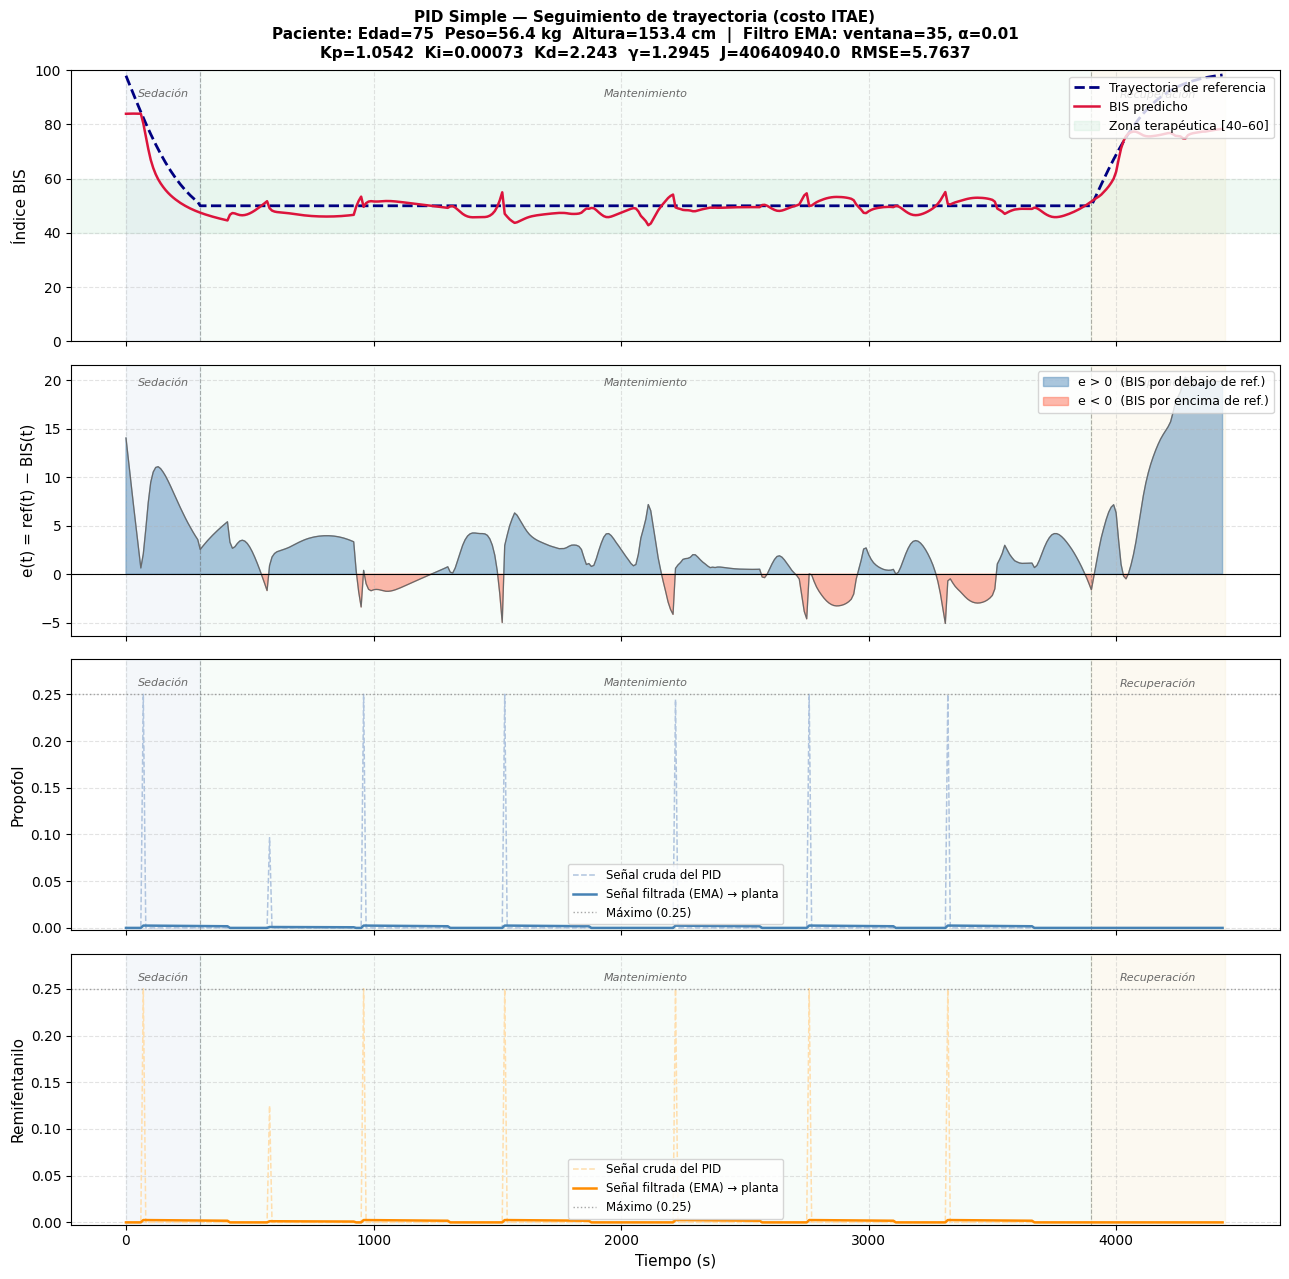

[INFO] Guardada: C:\Users\yordi\Desktop\exp4_pid_simple_trayectoria_itae.png


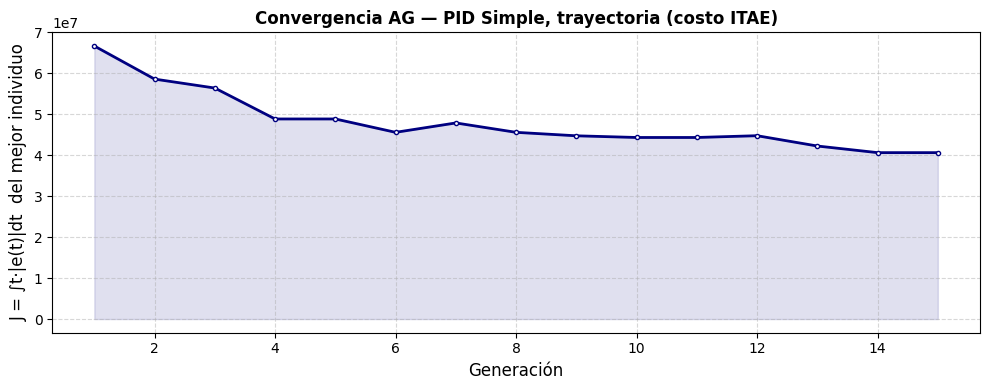

[INFO] Guardada: C:\Users\yordi\Desktop\exp4_pid_simple_trayectoria_convergencia.png


In [ ]:
# =============================================================================
# EXPERIMENTO 4  — PID SIMPLE: SEGUIMIENTO DE TRAYECTORIA
#                          (SEDACIÓN · MANTENIMIENTO · RECUPERACIÓN)
#                          CON FUNCIÓN DE COSTO ITAE
# =============================================================================
#
# Se sintoniza el PID Simple, conservando la arquitectura de filtrado por
# media exponencial móvil (EMA) definida en la Etapa 2, para que la
# respuesta BIS siga una trayectoria de referencia compuesta por tres
# fases clínicas:
#
#   Fase 1 — Sedación      (  0 –  300 s): f(t) = 98 + 56.8·tanh(−0.004·t)
#   Fase 2 — Mantenimiento (300 – 3900 s): f(t) = 50  (constante)
#   Fase 3 — Recuperación  (3900 – 4440 s): f(t) = 50 + 49.7·tanh(0.004·(t−3900))
#
# La función de costo se modifica respecto a los experimentos anteriores:
# en lugar de la integral del error al cuadrado, se emplea ahora la
# integral del tiempo multiplicado por el valor absoluto del error
# (criterio ITAE, por sus siglas en inglés):
#
#       J = ∫ t · |e(t)| dt ,      e(t) = BIS(t) − ref(t)
#
# El criterio ITAE penaliza con mayor severidad los errores que persisten
# en instantes avanzados de la simulación, favoreciendo sintonizaciones
# que corrigen rápidamente cualquier desviación sostenida de la referencia.


# =============================================================================
#  PARÁMETROS  
# =============================================================================

# ── Paciente ──────────────────────────────────────────────────────────────────
EDAD_E4, PESO_E4, ALTURA_E4, SEXO_E4 = 75, 56.4, 153.4, 1

# ── Duraciones de cada fase [s] ───────────────────────────────────────────────
T_SEDACION_E4      = 300     # Fase 1: sedación
T_MANTENIMIENTO_E4 = 3600    # Fase 2: mantenimiento
T_RECUPERACION_E4  = 540     # Fase 3: recuperación

# ── Coeficientes de las curvas analíticas ─────────────────────────────────────
# Sedación:      f(t)  = SED_A + SED_B · tanh(SED_K · t)
SED_A_E4, SED_B_E4, SED_K_E4 = 98.0, 56.8, -0.004
# Mantenimiento: BIS constante
BIS_MANT_E4 = 50.0
# Recuperación:  f(τ)  = REC_A + REC_B · tanh(REC_K · τ),  τ = t − t_inicio_rec
REC_A_E4, REC_B_E4, REC_K_E4 = 50.0, 49.7, 0.004

# ── Parámetros de simulación ──────────────────────────────────────────────────
DT_E4       = 10.0    # Período de muestreo [s]
T_VEN_E4    = 180     # Longitud de ventana del modelo [muestras]
PPF_MAX_E4  = 0.25    # Saturación máxima de propofol
REMI_MAX_E4 = 0.25    # Saturación máxima de remifentanilo

# ── Espacio de búsqueda [Kp, Ki, Kd, gamma] ──────────────────────────────────
limites_inf_e4 = [1e-8,1e-8, 1e-8, 1e-8]
limites_sup_e4 = [3,3,3,3]
nombres_e4     = ["Kp", "Ki", "Kd", "gamma"]

# ── Algoritmo genético ────────────────────────────────────────────────────────
cfg_ag_e4 = dict(
    n_pop              = 3000,
    n_elite            = 1200,
    n_gen              = 15,
    prob_mut_global    = 0.7,    # 70 % de los hijos mutan
    fraccion_gaussiana = 0.8,    # 80 % gaussiana / 20 % uniforme
    sigma_mut          = 0.7,
)


# =============================================================================
#  CONSTRUCCIÓN DE LA TRAYECTORIA DE REFERENCIA
# =============================================================================

N_SED_E4 = int(T_SEDACION_E4      / DT_E4)   
N_MAN_E4 = int(T_MANTENIMIENTO_E4 / DT_E4)   
N_REC_E4 = int(T_RECUPERACION_E4  / DT_E4)   
N_TOT_E4 = N_SED_E4 + N_MAN_E4 + N_REC_E4    


def construir_referencia_e4():
    """
    Construye el vector de referencia BIS para la trayectoria clínica
    completa a partir de los parámetros analíticos 

    Retorna
    -------
    ref : ndarray (N_TOT_E4,) — referencia BIS en cada muestra
    """
    ref = np.zeros(N_TOT_E4, dtype=np.float32)

    # Fase 1: sedación
    for i in range(N_SED_E4):
        t = i * DT_E4
        ref[i] = SED_A_E4 + SED_B_E4 * np.tanh(SED_K_E4 * t)

    # Fase 2: mantenimiento
    ref[N_SED_E4 : N_SED_E4 + N_MAN_E4] = BIS_MANT_E4

    # Fase 3: recuperación (τ es el tiempo local dentro de la fase)
    for i in range(N_REC_E4):
        tau = i * DT_E4
        ref[N_SED_E4 + N_MAN_E4 + i] = REC_A_E4 + REC_B_E4 * np.tanh(REC_K_E4 * tau)

    return ref


referencia_e4 = construir_referencia_e4()
eje_t_e4      = np.arange(N_TOT_E4) * DT_E4   # Eje temporal [s]

print(f"[INFO] Trayectoria construida: {N_TOT_E4} muestras "
      f"({N_TOT_E4 * DT_E4:.0f} s)")
print(f"       BIS inicial : {referencia_e4[0]:.2f}")
print(f"       BIS mínimo  : {referencia_e4.min():.2f}")
print(f"       BIS final   : {referencia_e4[-1]:.2f}")

ref_bis_tensor_e4 = torch.tensor(referencia_e4, dtype=torch.float32,
                                  device=dispositivo)


# =============================================================================
# SIMULACIÓN EN LOTE — PID SIMPLE CON TRAYECTORIA 
#            Y FUNCIÓN DE COSTO ITAE
#
# Conserva la arquitectura de filtrado EMA definida en la Etapa 2: las
# señales de control se filtran antes de introducirse a la planta. Se
# sustituye la referencia constante por un vector variable en el tiempo,
# y la función de costo por el criterio ITAE.
# =============================================================================

@torch.no_grad()
def simular_lote_pid_simple_tray_itae(poblacion, cov, *, ref_bis, bis_ini,
                                       T_sim, T_ven, dt, ppf_max, remi_max,
                                       ventana_ema=VENTANA_EMA,
                                       alfa_ema=ALFA_EMA):
    """
    Simula el lazo de control PID simple, con arquitectura de filtrado EMA,
    para seguir una referencia BIS variable en el tiempo. 

    Ley de control:
        e(t)         = BIS(t) − ref(t)
        u_ppf_crudo  = clamp(Kp·e + Ki·∫e·dt + Kd·Δe/Δt,  0, ppf_max)
        u_remi_crudo = clamp(γ · u_ppf_crudo,             0, remi_max)

    Filtrado (antes de introducirse a la planta):
        u_ppf  = EMA_ventana(u_ppf_crudo,  ventana_ema, alfa_ema)
        u_remi = EMA_ventana(u_remi_crudo, ventana_ema, alfa_ema)

    Función de costo (ITAE):
        J = ∫ t · |e(t)| dt

    Parámetros
    ----------
    poblacion : (N, 4)       — [Kp, Ki, Kd, gamma] por individuo
    cov       : (1, 4)       — covariables del paciente
    ref_bis   : (T_sim,)     — referencia BIS en cada instante

    Retorna
    -------
    costo          : (N,)        — valor de J para cada individuo
    ppf_filt_hist  : (N, T_sim)  — propofol filtrado (introducido a la planta)
    remi_filt_hist : (N, T_sim)  — remifentanilo filtrado
    bis_hist       : (N, T_sim)  — respuesta BIS simulada
    ppf_raw_hist   : (N, T_sim)  — propofol crudo 
    remi_raw_hist  : (N, T_sim)  — remifentanilo crudo
    """
    N   = poblacion.shape[0]
    Kp  = poblacion[:, 0]
    Ki  = poblacion[:, 1]
    Kd  = poblacion[:, 2]
    gam = poblacion[:, 3]

    ppf_raw_h   = torch.zeros(N, T_sim,     dtype=torch.float32, device=dispositivo)
    remi_raw_h  = torch.zeros(N, T_sim,     dtype=torch.float32, device=dispositivo)
    ppf_filt_h  = torch.zeros(N, T_sim,     dtype=torch.float32, device=dispositivo)
    remi_filt_h = torch.zeros(N, T_sim,     dtype=torch.float32, device=dispositivo)
    bis_h       = torch.zeros(N, T_sim + 1, dtype=torch.float32, device=dispositivo)
    bis_h[:, 0] = bis_ini

    # Integrador libre 
    integr   = torch.zeros(N, device=dispositivo)
    e_prev   = torch.zeros(N, device=dispositivo)
    costo    = torch.zeros(N, device=dispositivo)
    cov_lote = cov.expand(N, -1)

    for t in range(T_sim):
        e      = bis_h[:, t] - ref_bis[t]
        integr = integr + e * dt
        d_e    = (e - e_prev) / dt
        e_prev = e.clone()

        # ── Señal cruda del controlador ────────────────────────────────────────
        u_ppf_crudo  = (Kp * e + Ki * integr + Kd * d_e).clamp(0.0, ppf_max)
        u_remi_crudo = (gam * u_ppf_crudo).clamp(0.0, remi_max)

        ppf_raw_h[:, t]  = u_ppf_crudo
        remi_raw_h[:, t] = u_remi_crudo

        # ── Filtrado EMA antes de introducirse a la planta ─────────────────────
        u_ppf_filt  = filtro_ema_ventana(ppf_raw_h,  t, ventana_ema, alfa_ema)
        u_remi_filt = filtro_ema_ventana(remi_raw_h, t, ventana_ema, alfa_ema)

        ppf_filt_h[:, t]  = u_ppf_filt
        remi_filt_h[:, t] = u_remi_filt

        # ── Acumulación de la función de costo ITAE: J = ∫ t·|e(t)| dt ────────
        costo += (t * dt) * torch.abs(e) * dt

        # ── Construcción de ventanas normalizadas a partir de la señal
        #    filtrada, para inferencia del modelo predictor del BIS ───────────
        ini   = max(0, t - T_ven + 1)
        fin   = t + 1
        n_pad = T_ven - (fin - ini)
        if n_pad > 0:
            c   = torch.zeros(N, n_pad, device=dispositivo)
            v_p = torch.cat([c, ppf_filt_h[:, ini:fin]],  dim=1)
            v_r = torch.cat([c, remi_filt_h[:, ini:fin]], dim=1)
            v_b = torch.cat([c, bis_h[:, ini:fin]],       dim=1)
        else:
            v_p, v_r, v_b = (ppf_filt_h[:, ini:fin],
                              remi_filt_h[:, ini:fin],
                              bis_h[:, ini:fin])

        inf_t = torch.stack([normalizar_lote(v_p, n_pad),
                              normalizar_lote(v_r, n_pad)], dim=1)
        bis_pred, _ = modelo(inf_t, normalizar_lote(v_b, n_pad), cov_lote)
        bis_h[:, t + 1] = bis_pred

    return costo, ppf_filt_h, remi_filt_h, bis_h[:, 1:], ppf_raw_h, remi_raw_h


# =============================================================================
# SINTONIZACIÓN MEDIANTE ALGORITMO GENÉTICO
# =============================================================================

cov_e4 = hacer_cov_tensor(EDAD_E4, PESO_E4, ALTURA_E4, SEXO_E4)

lim_inf_e4_t = torch.tensor(limites_inf_e4, dtype=torch.float32, device=dispositivo)
lim_sup_e4_t = torch.tensor(limites_sup_e4, dtype=torch.float32, device=dispositivo)

cfg_sim_e4 = dict(
    ref_bis  = ref_bis_tensor_e4,
    bis_ini  = float(referencia_e4[0]),
    T_sim    = N_TOT_E4,
    T_ven    = T_VEN_E4,
    dt       = DT_E4,
    ppf_max  = PPF_MAX_E4,
    remi_max = REMI_MAX_E4,
    
)

elite_e4, hist_e4, hist_params_e4 = ejecutar_ag(
    simular_lote_pid_simple_tray_itae, cov_e4,
    lim_inf_e4_t, lim_sup_e4_t,
    cfg_sim_e4, cfg_ag_e4, nombres_e4,
    encabezado="PID SIMPLE — TRAYECTORIA (SEDACIÓN/MANTENIMIENTO/RECUPERACIÓN) — J = ITAE"
)

mejor_e4 = elite_e4[0]


# =============================================================================
# IMPRESIÓN DE PARÁMETROS EN CONSOLA
# =============================================================================

ancho = 66
print("\n" + "=" * ancho)
print("  RESULTADO FINAL — PID SIMPLE (trayectoria, costo ITAE)")
print(f"  J = ∫ t·|e(t)| dt")
print(f"  Paciente: Edad={EDAD_E4} años  Peso={PESO_E4} kg  "
      f"Altura={ALTURA_E4} cm  Sexo={'M' if SEXO_E4==0 else 'F'}")
print(f"  Filtro EMA: ventana={VENTANA_EMA}  α={ALFA_EMA}")
print("─" * ancho)
for j, n in enumerate(nombres_e4):
    print(f"  {n:>8} = {mejor_e4[j].item():.8f}")
print(f"  {'J óptimo':>8} = {hist_e4[-1]:.4f}")
print("=" * ancho)


# =============================================================================
# SIMULACIÓN FINAL CON EL MEJOR INDIVIDUO
# =============================================================================

(costo_final_e4, ppf_filt_e4, remi_filt_e4, bis_e4,
 ppf_raw_e4, remi_raw_e4) = simular_lote_pid_simple_tray_itae(
    mejor_e4.unsqueeze(0), cov_e4, **cfg_sim_e4
)

bis_np_e4       = bis_e4.squeeze(0).cpu().numpy()
ppf_filt_np_e4  = ppf_filt_e4.squeeze(0).cpu().numpy()
remi_filt_np_e4 = remi_filt_e4.squeeze(0).cpu().numpy()
ppf_raw_np_e4   = ppf_raw_e4.squeeze(0).cpu().numpy()
remi_raw_np_e4  = remi_raw_e4.squeeze(0).cpu().numpy()
error_np_e4     = referencia_e4 - bis_np_e4

# RMSE respecto a la trayectoria de referencia (informativo)
rmse_e4 = float(np.sqrt(np.mean(error_np_e4 ** 2)))
print(f"\n[INFO] RMSE de la sintonización final respecto a la trayectoria: "
      f"{rmse_e4:.4f}")


# =============================================================================
# FUNCIÓN AUXILIAR — MARCADO DE FASES CLÍNICAS EN EL EJE
# =============================================================================

def marcar_fases_e4(ax, ymin, ymax):
    """
    Dibuja bandas de color y etiquetas que delimitan las fases de
    sedación, mantenimiento y recuperación sobre un eje de Matplotlib.
    """
    t_s1, t_s2 = 0, T_SEDACION_E4
    t_m2       = T_SEDACION_E4 + T_MANTENIMIENTO_E4
    t_r2       = N_TOT_E4 * DT_E4

    ax.axvspan(t_s1, t_s2, alpha=0.06, color="steelblue",      zorder=0)
    ax.axvspan(t_s2, t_m2, alpha=0.04, color="mediumseagreen", zorder=0)
    ax.axvspan(t_m2, t_r2, alpha=0.06, color="goldenrod",      zorder=0)

    for t_lim in [t_s2, t_m2]:
        ax.axvline(t_lim, color="dimgray", lw=0.8, ls="--", alpha=0.5)

    yl = ymin + 0.93 * (ymax - ymin)
    for mid, lbl in [
        ((t_s1 + t_s2) / 2, "Sedación"),
        ((t_s2 + t_m2) / 2, "Mantenimiento"),
        ((t_m2 + t_r2) / 2, "Recuperación"),
    ]:
        ax.text(mid, yl, lbl, ha="center", va="top",
                fontsize=8, color="dimgray", style="italic")


# =============================================================================
#  GRÁFICA DEL RESULTADO 
# =============================================================================

fig, ejes = plt.subplots(4, 1, figsize=(13, 13), sharex=True)
fig.suptitle(
    "PID Simple — Seguimiento de trayectoria (costo ITAE)\n"
    f"Paciente: Edad={EDAD_E4}  Peso={PESO_E4} kg  Altura={ALTURA_E4} cm  |  "
    f"Filtro EMA: ventana={VENTANA_EMA}, α={ALFA_EMA}\n"
    f"Kp={mejor_e4[0].item():.4f}  Ki={mejor_e4[1].item():.5f}  "
    f"Kd={mejor_e4[2].item():.3f}  γ={mejor_e4[3].item():.4f}  "
    f"J={hist_e4[-1]:.1f}  RMSE={rmse_e4:.4f}",
    fontsize=11, fontweight="bold"
)

# ── Panel 1: BIS vs. trayectoria de referencia ────────────────────────────────
ax = ejes[0]
ax.plot(eje_t_e4, referencia_e4, color="navy", lw=2.0, ls="--",
        label="Trayectoria de referencia", zorder=3)
ax.plot(eje_t_e4, bis_np_e4, color="crimson", lw=1.8,
        label="BIS predicho", zorder=4)
ax.axhspan(40, 60, alpha=0.08, color="mediumseagreen",
           label="Zona terapéutica [40–60]")
marcar_fases_e4(ax, 0, 100)
ax.set_ylabel("Índice BIS", fontsize=11)
ax.set_ylim(0, 100)
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, ls="--", alpha=0.35)

# ── Panel 2: Error de seguimiento ─────────────────────────────────────────────
ax = ejes[1]
ax.fill_between(eje_t_e4, error_np_e4, 0, where=(error_np_e4 >= 0),
                interpolate=True, color="steelblue", alpha=0.45,
                label="e > 0  (BIS por debajo de ref.)")
ax.fill_between(eje_t_e4, error_np_e4, 0, where=(error_np_e4 < 0),
                interpolate=True, color="tomato", alpha=0.45,
                label="e < 0  (BIS por encima de ref.)")
ax.plot(eje_t_e4, error_np_e4, color="dimgray", lw=0.9)
ax.axhline(0, color="black", lw=0.8)
marcar_fases_e4(ax, float(error_np_e4.min()) - 2, float(error_np_e4.max()) + 2)
ax.set_ylabel("e(t) = ref(t) − BIS(t)", fontsize=11)
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, ls="--", alpha=0.35)

# ── Panel 3: Propofol (cruda vs. filtrada) ───────────────────────────────────
ax = ejes[2]
ax.plot(eje_t_e4, ppf_raw_np_e4, color="lightsteelblue", lw=1.1, ls="--",
        label="Señal cruda del PID", zorder=2)
ax.plot(eje_t_e4, ppf_filt_np_e4, color="steelblue", lw=1.8,
        label="Señal filtrada (EMA) → planta", zorder=3)
ax.axhline(PPF_MAX_E4, color="gray", ls=":", lw=1, alpha=0.7,
           label=f"Máximo ({PPF_MAX_E4})")
marcar_fases_e4(ax, -0.01 * PPF_MAX_E4, PPF_MAX_E4 * 1.15)
ax.set_ylabel("Propofol", fontsize=11)
ax.set_ylim(-0.01 * PPF_MAX_E4, PPF_MAX_E4 * 1.15)
ax.legend(fontsize=8.5)
ax.grid(True, ls="--", alpha=0.35)

# ── Panel 4: Remifentanilo (cruda vs. filtrada) ───────────────────────────────
ax = ejes[3]
ax.plot(eje_t_e4, remi_raw_np_e4, color="navajowhite", lw=1.1, ls="--",
        label="Señal cruda del PID", zorder=2)
ax.plot(eje_t_e4, remi_filt_np_e4, color="darkorange", lw=1.8,
        label="Señal filtrada (EMA) → planta", zorder=3)
ax.axhline(REMI_MAX_E4, color="gray", ls=":", lw=1, alpha=0.7,
           label=f"Máximo ({REMI_MAX_E4})")
marcar_fases_e4(ax, -0.01 * REMI_MAX_E4, REMI_MAX_E4 * 1.15)
ax.set_ylabel("Remifentanilo", fontsize=11)
ax.set_xlabel("Tiempo (s)", fontsize=11)
ax.set_ylim(-0.01 * REMI_MAX_E4, REMI_MAX_E4 * 1.15)
ax.legend(fontsize=8.5)
ax.grid(True, ls="--", alpha=0.35)

plt.tight_layout()
ruta_e4 = os.path.join(RUTA_GRAFICAS, "exp4_pid_simple_trayectoria_itae.png")
plt.savefig(ruta_e4, dpi=150, bbox_inches="tight")
plt.show()
print(f"[INFO] Guardada: {ruta_e4}")



graficar_convergencia(
    hist_e4,
    "Convergencia AG — PID Simple, trayectoria (costo ITAE)",
    "exp4_pid_simple_trayectoria_convergencia.png",
    etiqueta_y="J = ∫t·|e(t)|dt  del mejor individuo"
)

##  Sintonización poblacional 

In [ ]:

# Se lee el archivo Poblacion_Prueba.csv. Cada fila corresponde a un paciente, con las columnas Edad,
# Peso, Altura y Sexo (caracteres 'M' o 'F').
#
# Para cada paciente se sintoniza el PID Simple, empleando la misma
# arquitectura de filtrado por media exponencial móvil (EMA), la misma
# trayectoria clínica de tres fases y la misma función de costo ITAE
# definidas, mediante Algoritmo Genético:
#
#       J = ∫ t · |e(t)| dt
#
# Los resultados —datos del paciente, hiperparámetros del mejor PID
# Simple obtenido y RMSE de dicha sintonización— se organizan en un
# DataFrame y se exportan al archivo SINTONIZACIONES.csv.

import pandas as pd
import sys
import time
import matplotlib.cm as cm

# =============================================================================
# PARÁMETROS 
# =============================================================================

# ── Rutas  ────────────────────────────────────────────────────────────────────
RUTA_POBLACION_PRUEBA = "Poblacion_Prueba.csv"
RUTA_SINTONIZACIONES  = "SINTONIZACIONES.csv"

# ── Duraciones de cada fase [s] ───────────────────────────────────────────────
T_SEDACION_E5      = 300     # Fase 1: sedación
T_MANTENIMIENTO_E5 = 3600    # Fase 2: mantenimiento
T_RECUPERACION_E5  = 540     # Fase 3: recuperación

# ── Coeficientes de las curvas analíticas ─────────────────────────────────────
SED_A_E5, SED_B_E5, SED_K_E5 = 98.0, 56.8, -0.004
BIS_MANT_E5                  = 50.0
REC_A_E5, REC_B_E5, REC_K_E5 = 50.0, 49.7, 0.004

# ── Parámetros de simulación ──────────────────────────────────────────────────
DT_E5       = 10.0
T_VEN_E5    = 180
PPF_MAX_E5  = 0.25
REMI_MAX_E5 = 0.25

# ── Hiperparámetros del filtro EMA ────────────────────────────────────────────
VENTANA_EMA_E5 = VENTANA_EMA   
ALFA_EMA_E5    = ALFA_EMA      

# ── Espacio de búsqueda [Kp, Ki, Kd, gamma] ──────────────────────────────────
limites_inf_e5 = [1e-8, 1e-8, 1e-8,  1e-8]
limites_sup_e5 = [3.0,  3.0,     3.0,  3.0]
nombres_e5     = ["Kp", "Ki", "Kd", "gamma"]

# ── Algoritmo genético ────────────────────────────────────────────────────────
cfg_ag_e5 = dict(
    n_pop              = 3000,
    n_elite            = 1200,
    n_gen              = 15,
    prob_mut_global    = 0.7,
    fraccion_gaussiana = 0.8,
    sigma_mut          = 0.7,
)


# =============================================================================
# CONSTRUCCIÓN DE LA TRAYECTORIA DE REFERENCIA
# =============================================================================

N_SED_E5 = int(T_SEDACION_E5      / DT_E5)
N_MAN_E5 = int(T_MANTENIMIENTO_E5 / DT_E5)
N_REC_E5 = int(T_RECUPERACION_E5  / DT_E5)
N_TOT_E5 = N_SED_E5 + N_MAN_E5 + N_REC_E5

_ref_e5 = np.zeros(N_TOT_E5, dtype=np.float32)

for _i in range(N_SED_E5):
    _ref_e5[_i] = SED_A_E5 + SED_B_E5 * np.tanh(SED_K_E5 * _i * DT_E5)

_ref_e5[N_SED_E5 : N_SED_E5 + N_MAN_E5] = BIS_MANT_E5

for _i in range(N_REC_E5):
    _ref_e5[N_SED_E5 + N_MAN_E5 + _i] = (
        REC_A_E5 + REC_B_E5 * np.tanh(REC_K_E5 * _i * DT_E5)
    )

ref_bis_e5_t = torch.tensor(_ref_e5, dtype=torch.float32, device=dispositivo)
eje_t_e5     = np.arange(N_TOT_E5) * DT_E5

print(f"[INFO] Trayectoria construida: {N_TOT_E5} muestras "
      f"({N_TOT_E5 * DT_E5:.0f} s)")

cfg_sim_e5 = dict(
    ref_bis     = ref_bis_e5_t,
    bis_ini     = float(_ref_e5[0]),
    T_sim       = N_TOT_E5,
    T_ven       = T_VEN_E5,
    dt          = DT_E5,
    ppf_max     = PPF_MAX_E5,
    remi_max    = REMI_MAX_E5,
    ventana_ema = VENTANA_EMA_E5,
    alfa_ema    = ALFA_EMA_E5,
)

lim_inf_e5_t = torch.tensor(limites_inf_e5, dtype=torch.float32, device=dispositivo)
lim_sup_e5_t = torch.tensor(limites_sup_e5, dtype=torch.float32, device=dispositivo)


# =============================================================================
# SIMULACIÓN EN LOTE — PID SIMPLE CON TRAYECTORIA VARIABLE
#            Y FUNCIÓN DE COSTO ITAE
# =============================================================================

@torch.no_grad()
def simular_lote_pid_simple_trayectoria(poblacion, cov, *, ref_bis, bis_ini,
                                         T_sim, T_ven, dt, ppf_max, remi_max,
                                         ventana_ema=VENTANA_EMA,
                                         alfa_ema=ALFA_EMA):
    """
    Simula el lazo de control PID simple, con arquitectura de filtrado
    EMA, para una referencia BIS variable en el tiempo. 

    Ley de control:
        e(t)         = BIS(t) − ref(t)
        u_ppf_crudo  = clamp(Kp·e + Ki·∫e·dt + Kd·Δe/Δt, 0, ppf_max)
        u_remi_crudo = clamp(γ · u_ppf_crudo, 0, remi_max)

    Filtrado:
        u_ppf  = EMA_ventana(u_ppf_crudo,  ventana_ema, alfa_ema)
        u_remi = EMA_ventana(u_remi_crudo, ventana_ema, alfa_ema)

    Función de costo (ITAE):
        J = ∫ t · |e(t)| dt

    Parámetros
    ----------
    poblacion : (N, 4) — [Kp, Ki, Kd, gamma]
    cov       : (1, 4) — covariables del paciente
    ref_bis   : (T_sim,) — referencia BIS en cada instante

    Retorna
    -------
    costo, ppf_filt_hist, remi_filt_hist, bis_hist, ppf_raw_hist, remi_raw_hist
    """
    N   = poblacion.shape[0]
    Kp  = poblacion[:, 0]
    Ki  = poblacion[:, 1]
    Kd  = poblacion[:, 2]
    gam = poblacion[:, 3]

    ppf_raw_h   = torch.zeros(N, T_sim,     dtype=torch.float32, device=dispositivo)
    remi_raw_h  = torch.zeros(N, T_sim,     dtype=torch.float32, device=dispositivo)
    ppf_filt_h  = torch.zeros(N, T_sim,     dtype=torch.float32, device=dispositivo)
    remi_filt_h = torch.zeros(N, T_sim,     dtype=torch.float32, device=dispositivo)
    bis_h       = torch.zeros(N, T_sim + 1, dtype=torch.float32, device=dispositivo)
    bis_h[:, 0] = bis_ini

    # Integrador
    integr   = torch.zeros(N, device=dispositivo)
    e_prev   = torch.zeros(N, device=dispositivo)
    costo    = torch.zeros(N, device=dispositivo)
    cov_lote = cov.expand(N, -1)

    for t in range(T_sim):
        e      = bis_h[:, t] - ref_bis[t]
        integr = integr + e * dt
        d_e    = (e - e_prev) / dt
        e_prev = e.clone()

        u_ppf_crudo  = (Kp * e + Ki * integr + Kd * d_e).clamp(0.0, ppf_max)
        u_remi_crudo = (gam * u_ppf_crudo).clamp(0.0, remi_max)

        ppf_raw_h[:, t]  = u_ppf_crudo
        remi_raw_h[:, t] = u_remi_crudo

        # ── Filtrado EMA antes de introducirse a la planta ─────────────────────
        u_ppf_filt  = filtro_ema_ventana(ppf_raw_h,  t, ventana_ema, alfa_ema)
        u_remi_filt = filtro_ema_ventana(remi_raw_h, t, ventana_ema, alfa_ema)

        ppf_filt_h[:, t]  = u_ppf_filt
        remi_filt_h[:, t] = u_remi_filt

        # ── Acumulación de la función de costo ITAE: J = ∫ t·|e(t)| dt ─────────
        costo += (t * dt) * torch.abs(e) * dt

        # ── Construcción de ventanas normalizadas a partir de la señal
        #    filtrada, para inferencia del modelo predictor del BIS ───────────
        ini   = max(0, t - T_ven + 1)
        fin   = t + 1
        n_pad = T_ven - (fin - ini)
        if n_pad > 0:
            c   = torch.zeros(N, n_pad, device=dispositivo)
            v_p = torch.cat([c, ppf_filt_h[:, ini:fin]],  dim=1)
            v_r = torch.cat([c, remi_filt_h[:, ini:fin]], dim=1)
            v_b = torch.cat([c, bis_h[:, ini:fin]],       dim=1)
        else:
            v_p, v_r, v_b = (ppf_filt_h[:, ini:fin],
                              remi_filt_h[:, ini:fin],
                              bis_h[:, ini:fin])

        inf_t = torch.stack([normalizar_lote(v_p, n_pad),
                              normalizar_lote(v_r, n_pad)], dim=1)
        bis_pred, _ = modelo(inf_t, normalizar_lote(v_b, n_pad), cov_lote)
        bis_h[:, t + 1] = bis_pred

    return costo, ppf_filt_h, remi_filt_h, bis_h[:, 1:], ppf_raw_h, remi_raw_h


# =============================================================================
# FUNCIÓN AUXILIAR — BARRA DE PROGRESO 
# =============================================================================

def barra_progreso(actual: int, total: int, ancho: int = 45,
                    t_inicio: float = None) -> None:
    """
    Imprime en consola una barra de progreso textual con porcentaje y
    tiempo estimado de finalización.

    Parámetros
    ----------
    actual   : número de pacientes procesados hasta el momento
    total    : número total de pacientes
    ancho    : longitud en caracteres de la barra interior
    t_inicio : marca de tiempo (time.time()) del inicio del proceso
    """
    fraccion   = actual / total
    completado = int(ancho * fraccion)
    barra      = "█" * completado + "░" * (ancho - completado)
    porcentaje = fraccion * 100.0

    if t_inicio is not None:
        transcurrido = time.time() - t_inicio
        if actual > 0:
            eta = transcurrido * (total - actual) / actual
            tiempo_str = f"  {transcurrido:6.0f}s transcurridos  ETA {eta:6.0f}s"
        else:
            tiempo_str = ""
    else:
        tiempo_str = ""

    linea = f"\r  [{barra}] {porcentaje:5.1f}%  ({actual}/{total}){tiempo_str}"
    sys.stdout.write(linea)
    sys.stdout.flush()
    if actual == total:
        sys.stdout.write("\n")
        sys.stdout.flush()


# =============================================================================
# CARGA DEL ARCHIVO DE PACIENTES
# =============================================================================

print(f"[INFO] Cargando pacientes desde: {RUTA_POBLACION_PRUEBA}")

try:
    df_pacientes_e5 = pd.read_csv(RUTA_POBLACION_PRUEBA)
except FileNotFoundError:
    raise FileNotFoundError(
        f"No se encontró el archivo '{RUTA_POBLACION_PRUEBA}' "
        
    )

columnas_requeridas_e5 = {"Edad", "Peso", "Altura", "Sexo"}
faltantes_e5 = columnas_requeridas_e5 - set(df_pacientes_e5.columns)
if faltantes_e5:
    raise ValueError(
        f"El archivo CSV no contiene las columnas esperadas: {faltantes_e5}. "
        f"Columnas encontradas: {list(df_pacientes_e5.columns)}"
    )

# Conversión del campo Sexo: 'M' → 0, 'F' → 1
df_pacientes_e5["Sexo_num"] = (
    df_pacientes_e5["Sexo"].str.strip().str.upper().map({"M": 0, "F": 1})
)

N_PAC_E5 = len(df_pacientes_e5)
print(f"[INFO] Pacientes cargados: {N_PAC_E5}")


# =============================================================================
# BARRIDO POBLACIONAL — SINTONIZACIÓN DEL PID SIMPLE
# =============================================================================

registros_e5    = []   # Filas del DataFrame final
historiales_e5  = []   # Señales BIS y RMSE
t_inicio_e5     = time.time()

print("\n" + "=" * 70)
print("  SINTONIZACIÓN POBLACIONAL — PID SIMPLE (trayectoria, ITAE)")
print(f"  Pacientes: {N_PAC_E5}")
print("=" * 70)

for idx, fila in df_pacientes_e5.iterrows():

    edad, peso, altura = float(fila["Edad"]), float(fila["Peso"]), float(fila["Altura"])
    sexo     = int(fila["Sexo_num"])
    sexo_str = "M" if sexo == 0 else "F"
    num_pac  = idx + 1

    print(f"\n  Paciente {num_pac}/{N_PAC_E5}  |  Edad={edad:.0f}  "
          f"Peso={peso:.1f} kg  Altura={altura:.1f} cm  Sexo={sexo_str}")

    cov_pac = hacer_cov_tensor(edad, peso, altura, sexo)

    # ── Sintonización mediante Algoritmo Genético ─────────────────────────────
    elite_pac, hist_pac, _ = ejecutar_ag(
        simular_lote_pid_simple_trayectoria, cov_pac,
        lim_inf_e5_t, lim_sup_e5_t,
        cfg_sim_e5, cfg_ag_e5, nombres_e5,
        encabezado=f"PID Simple — Pac.{num_pac} ({sexo_str}, {edad:.0f}a, {peso:.1f}kg)"
    )
    mejor_pac = elite_pac[0]

    # ── Simulación final con el mejor individuo ───────────────────────────────
    (_, _, _, bis_pac_t, _, _) = simular_lote_pid_simple_trayectoria(
        mejor_pac.unsqueeze(0), cov_pac, **cfg_sim_e5
    )
    bis_np_pac = bis_pac_t.squeeze(0).cpu().numpy()
    rmse_pac   = float(np.sqrt(np.mean((bis_np_pac - _ref_e5) ** 2)))

    print(f"\n  ► RMSE Pac.{num_pac}: {rmse_pac:.4f}   "
          f"J óptimo = {hist_pac[-1]:.2f}")
    for j, nm in enumerate(nombres_e5):
        print(f"    {nm:<8} = {mejor_pac[j].item():.8f}")

    # ── Actualización de la barra de progreso ─────────────────────────────────
    barra_progreso(num_pac, N_PAC_E5, t_inicio=t_inicio_e5)

    historiales_e5.append({
        "bis"     : bis_np_pac,
        "rmse"    : rmse_pac,
        "etiqueta": f"Pac.{num_pac} ({sexo_str},{edad:.0f}a,{peso:.0f}kg)",
    })

    registros_e5.append({
        "Edad"   : edad,
        "Peso"   : peso,
        "Altura" : altura,
        "Sexo"   : sexo_str,
        "Kp"     : mejor_pac[0].item(),
        "Ki"     : mejor_pac[1].item(),
        "Kd"     : mejor_pac[2].item(),
        "gamma"  : mejor_pac[3].item(),
        "RMSE"   : rmse_pac,
    })


# =============================================================================
# CONSTRUCCIÓN DEL DATAFRAME Y EXPORTACIÓN A CSV
# =============================================================================

df_sintonizaciones = pd.DataFrame(
    registros_e5,
    columns=["Edad", "Peso", "Altura", "Sexo", "Kp", "Ki", "Kd", "gamma", "RMSE"]
)
df_sintonizaciones.to_csv(RUTA_SINTONIZACIONES, index=False, float_format="%.8f")

t_total_e5 = time.time() - t_inicio_e5

print("\n" + "=" * 70)
print("  SINTONIZACIÓN POBLACIONAL COMPLETADA")
print("=" * 70)
print(f"  Pacientes procesados : {N_PAC_E5}")
print(f"  Tiempo total         : {t_total_e5/60:.1f} min  ({t_total_e5:.0f} s)")
print(f"  Archivo guardado     : {RUTA_SINTONIZACIONES}")
print(f"  RMSE promedio        : {df_sintonizaciones['RMSE'].mean():.4f}")
print(f"  RMSE mín / máx       : {df_sintonizaciones['RMSE'].min():.4f} / "
      f"{df_sintonizaciones['RMSE'].max():.4f}")
print("=" * 70)

try:
    display(df_sintonizaciones)
except NameError:
    print(df_sintonizaciones.to_string(index=False))


# =============================================================================
# FUNCIÓN AUXILIAR — MARCADO DE LAS TRES FASES CLÍNICAS
# =============================================================================

def marcar_fases_e5(ax, ymin, ymax):
    """
    Dibuja bandas de color y etiquetas que delimitan las fases de
    sedación, mantenimiento y recuperación sobre un eje de Matplotlib.
    """
    t_s1, t_s2 = 0, T_SEDACION_E5
    t_m2       = T_SEDACION_E5 + T_MANTENIMIENTO_E5
    t_r2       = N_TOT_E5 * DT_E5

    ax.axvspan(t_s1, t_s2, alpha=0.06, color="steelblue",      zorder=0)
    ax.axvspan(t_s2, t_m2, alpha=0.04, color="mediumseagreen", zorder=0)
    ax.axvspan(t_m2, t_r2, alpha=0.06, color="goldenrod",      zorder=0)
    for t_lim in [t_s2, t_m2]:
        ax.axvline(t_lim, color="dimgray", lw=0.8, ls="--", alpha=0.5)

    yl = ymin + 0.93 * (ymax - ymin)
    for mid, lbl in [
        ((t_s1 + t_s2) / 2, "Sedación"),
        ((t_s2 + t_m2) / 2, "Mantenimiento"),
        ((t_m2 + t_r2) / 2, "Recuperación"),
    ]:
        ax.text(mid, yl, lbl, ha="center", va="top",
                fontsize=8, color="dimgray", style="italic")



[INFO] Trayectoria construida: 444 muestras (4440 s)
[INFO] Cargando pacientes desde: Poblacion_Prueba.csv
[INFO] Pacientes cargados: 340

  SINTONIZACIÓN POBLACIONAL — PID SIMPLE (trayectoria, ITAE)
  Pacientes: 340

  Paciente 1/340  |  Edad=69  Peso=62.8 kg  Altura=166.5 cm  Sexo=M

  PID Simple — Pac.1 (M, 69a, 62.8kg)
  Gen   1/15  Costo=84121032.00  Kp=0.5860  Ki=0.0002  Kd=0.9103  gamma=1.5610  [50.5s]
  Gen   2/15  Costo=82339288.00  Kp=2.2693  Ki=0.1361  Kd=0.7056  gamma=0.5852  [50.2s]
  Gen   3/15  Costo=82334560.00  Kp=2.2693  Ki=0.1361  Kd=0.7056  gamma=0.5852  [56.3s]
  Gen   4/15  Costo=82334560.00  Kp=2.2693  Ki=0.1361  Kd=0.7056  gamma=0.5852  [57.4s]
  Gen   5/15  Costo=82334560.00  Kp=2.2693  Ki=0.1361  Kd=0.7056  gamma=0.5852  [57.6s]
  Gen   6/15  Costo=82334560.00  Kp=2.2693  Ki=0.1361  Kd=0.7056  gamma=0.5852  [54.0s]
  Gen   7/15  Costo=82334560.00  Kp=2.2693  Ki=0.1361  Kd=0.7056  gamma=0.5852  [57.6s]
  Gen   8/15  Costo=82334560.00  Kp=2.2693  Ki=0.1361  Kd=0

,Edad,Peso,Altura,Sexo,Kp,Ki,Kd,gamma,RMSE
0,69.0,62.80,166.5,M,2.804704,0.014627,1.470263,0.178903,17.239843
1,46.0,81.80,174.5,M,1.156239,0.001394,0.477922,1.865874,12.129439
2,38.0,62.00,175.0,M,1.841619,0.011363,0.380515,0.025481,15.867215
3,69.0,68.25,170.0,M,2.370397,0.003067,1.472311,1.095958,16.056152
4,58.0,82.80,166.4,M,1.812955,0.002014,1.748188,2.533071,14.627651
...,...,...,...,...,...,...,...,...,...
335,42.0,69.80,165.1,F,0.857921,0.001114,1.883429,1.127371,8.222401
336,53.0,54.50,151.9,F,2.412171,0.002763,2.174127,1.178737,5.177191
337,49.0,56.20,157.6,F,2.781495,0.004914,0.900743,2.629919,13.160338
338,84.0,48.95,141.8,F,2.978966,0.001374,0.907019,0.173381,9.135205
